# Modeling and Evaluation

## Stage 9: Train-Test Split and Preprocessing Pipeline

This stage prepares the dataset for machine-learning models.

The data is divided into stratified training and test sets using an
80/20 ratio. Rule-based corrections are applied before splitting, while
all learned preprocessing operations are fitted only on the training
data.

Two preprocessing configurations are created: one including the dataset
source feature and another excluding it.

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    StandardScaler,
)


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Project root:")
print(PROJECT_ROOT)

print("\nData path:")
print(DATA_PATH)

print("\nData file exists:")
print(DATA_PATH.exists())

Project root:
E:\Projects\DataMining

Data path:
E:\Projects\DataMining\data\raw\data.csv

Data file exists:
True


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The dataset file was not found.\n"
        f"Checked path: {DATA_PATH}"
    )


df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()


print("Dataset loaded successfully.")
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

Dataset loaded successfully.
Number of rows: 920
Number of columns: 16


In [4]:
ID_COLUMN = "id"
TARGET_COLUMN = "num"


NUMERIC_FEATURES = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
]


CATEGORICAL_FEATURES_WITH_DATASET = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
]


CATEGORICAL_FEATURES_WITHOUT_DATASET = [
    feature
    for feature in CATEGORICAL_FEATURES_WITH_DATASET
    if feature != "dataset"
]


FEATURES_WITH_DATASET = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES_WITH_DATASET
)


FEATURES_WITHOUT_DATASET = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES_WITHOUT_DATASET
)


required_columns = (
    [ID_COLUMN, TARGET_COLUMN]
    + FEATURES_WITH_DATASET
)


missing_columns = [
    column
    for column in required_columns
    if column not in df_raw.columns
]


if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )


print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(
    "Categorical features with dataset: "
    f"{len(CATEGORICAL_FEATURES_WITH_DATASET)}"
)
print(
    "Categorical features without dataset: "
    f"{len(CATEGORICAL_FEATURES_WITHOUT_DATASET)}"
)

Numeric features: 5
Categorical features with dataset: 9
Categorical features without dataset: 8


In [5]:
X_model = df_raw.drop(
    columns=[
        ID_COLUMN,
        TARGET_COLUMN,
    ]
).copy(deep=True)


y = df_raw[TARGET_COLUMN].astype(int).copy()


SUSPICIOUS_ZERO_FEATURES = [
    "trestbps",
    "chol",
]


zero_replacement_rows = []


for feature in SUSPICIOUS_ZERO_FEATURES:
    zero_count = int(
        (X_model[feature] == 0).sum()
    )

    original_missing_count = int(
        X_model[feature].isna().sum()
    )

    X_model[feature] = X_model[feature].replace(
        0,
        np.nan,
    )

    adjusted_missing_count = int(
        X_model[feature].isna().sum()
    )

    zero_replacement_rows.append(
        {
            "feature": feature,
            "zero_values_replaced": zero_count,
            "original_missing_count": original_missing_count,
            "adjusted_missing_count": adjusted_missing_count,
        }
    )


zero_replacement_report = pd.DataFrame(
    zero_replacement_rows
)


display(zero_replacement_report)

,feature,zero_values_replaced,original_missing_count,adjusted_missing_count
0,trestbps,1,59,60
1,chol,172,30,202


In [6]:
def normalize_category_value(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return str(bool(value))

    if isinstance(value, (int, np.integer)):
        return str(int(value))

    if isinstance(value, (float, np.floating)):
        numeric_value = float(value)

        if numeric_value.is_integer():
            return str(int(numeric_value))

    return str(value)


for feature in CATEGORICAL_FEATURES_WITH_DATASET:
    X_model[feature] = X_model[feature].map(
        normalize_category_value
    )


categorical_type_summary = pd.DataFrame(
    {
        "feature": CATEGORICAL_FEATURES_WITH_DATASET,
        "data_type": [
            str(X_model[feature].dtype)
            for feature in CATEGORICAL_FEATURES_WITH_DATASET
        ],
        "missing_count": [
            int(X_model[feature].isna().sum())
            for feature in CATEGORICAL_FEATURES_WITH_DATASET
        ],
        "unique_non_missing_values": [
            int(
                X_model[feature].nunique(
                    dropna=True
                )
            )
            for feature in CATEGORICAL_FEATURES_WITH_DATASET
        ],
    }
)


display(categorical_type_summary)

,feature,data_type,missing_count,unique_non_missing_values
0,sex,object,0,2
1,dataset,object,0,4
2,cp,object,0,4
3,fbs,object,90,2
4,restecg,object,2,3
5,exang,object,55,2
6,slope,object,309,3
7,ca,object,611,4
8,thal,object,486,3


In [7]:
RANDOM_STATE = 42
TEST_SIZE = 0.20


X_train, X_test, y_train, y_test = (
    train_test_split(
        X_model,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )
)


print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

print(
    "\nTraining percentage: "
    f"{len(X_train) / len(X_model) * 100:.1f}%"
)

print(
    "Test percentage: "
    f"{len(X_test) / len(X_model) * 100:.1f}%"
)

Training rows: 736
Test rows: 184

Training percentage: 80.0%
Test percentage: 20.0%


In [8]:
def build_target_distribution(target_values, split_name):
    distribution = (
        target_values
        .value_counts()
        .sort_index()
        .rename_axis("target_class")
        .reset_index(name="count")
    )

    distribution["percent"] = (
        distribution["count"]
        / len(target_values)
        * 100
    )

    distribution.insert(
        0,
        "split",
        split_name,
    )

    return distribution


train_target_distribution = (
    build_target_distribution(
        target_values=y_train,
        split_name="train",
    )
)


test_target_distribution = (
    build_target_distribution(
        target_values=y_test,
        split_name="test",
    )
)


print("Training target distribution:")
display(train_target_distribution.round(2))


print("Test target distribution:")
display(test_target_distribution.round(2))

Training target distribution:


,split,target_class,count,percent
0,train,0,329,44.70
1,train,1,212,28.80
2,train,2,87,11.82
3,train,3,86,11.68
4,train,4,22,2.99


Test target distribution:


,split,target_class,count,percent
0,test,0,82,44.57
1,test,1,53,28.80
2,test,2,22,11.96
3,test,3,21,11.41
4,test,4,6,3.26


In [9]:
train_assignments = pd.DataFrame(
    {
        "row_index": X_train.index,
        "record_id": df_raw.loc[
            X_train.index,
            ID_COLUMN,
        ].to_numpy(),
        "target_class": y_train.to_numpy(),
        "split": "train",
    }
)


test_assignments = pd.DataFrame(
    {
        "row_index": X_test.index,
        "record_id": df_raw.loc[
            X_test.index,
            ID_COLUMN,
        ].to_numpy(),
        "target_class": y_test.to_numpy(),
        "split": "test",
    }
)


split_assignments = pd.concat(
    [
        train_assignments,
        test_assignments,
    ],
    ignore_index=True,
)


split_assignments = split_assignments.sort_values(
    by="row_index"
).reset_index(drop=True)


display(split_assignments.head())

,row_index,record_id,target_class,split
0,0,1,0,train
1,1,2,2,train
2,2,3,1,test
3,3,4,0,test
4,4,5,0,train


In [10]:
def build_preprocessor(
    numeric_features,
    categorical_features,
    numeric_imputation_strategy="median",
    scaler_name="standard",
):
    valid_imputation_strategies = {
        "mean",
        "median",
    }

    if (
        numeric_imputation_strategy
        not in valid_imputation_strategies
    ):
        raise ValueError(
            "Numeric imputation strategy must be "
            "'mean' or 'median'."
        )

    if scaler_name == "standard":
        scaler = StandardScaler()
    elif scaler_name == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError(
            "Scaler name must be "
            "'standard' or 'minmax'."
        )

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy=numeric_imputation_strategy
                ),
            ),
            (
                "scaler",
                scaler,
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Missing",
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    preprocessor.set_output(
        transform="pandas"
    )

    return preprocessor

In [11]:
preprocessor_with_dataset = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=(
        CATEGORICAL_FEATURES_WITH_DATASET
    ),
    numeric_imputation_strategy="median",
    scaler_name="standard",
)


preprocessor_without_dataset = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=(
        CATEGORICAL_FEATURES_WITHOUT_DATASET
    ),
    numeric_imputation_strategy="median",
    scaler_name="standard",
)


print("Preprocessors created successfully.")

Preprocessors created successfully.


In [12]:
X_train_with_dataset = X_train[
    FEATURES_WITH_DATASET
].copy()


X_test_with_dataset = X_test[
    FEATURES_WITH_DATASET
].copy()


X_train_without_dataset = X_train[
    FEATURES_WITHOUT_DATASET
].copy()


X_test_without_dataset = X_test[
    FEATURES_WITHOUT_DATASET
].copy()


X_train_transformed_with_dataset = (
    preprocessor_with_dataset.fit_transform(
        X_train_with_dataset
    )
)


X_test_transformed_with_dataset = (
    preprocessor_with_dataset.transform(
        X_test_with_dataset
    )
)


X_train_transformed_without_dataset = (
    preprocessor_without_dataset.fit_transform(
        X_train_without_dataset
    )
)


X_test_transformed_without_dataset = (
    preprocessor_without_dataset.transform(
        X_test_without_dataset
    )
)


print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [13]:
transformed_shape_summary = pd.DataFrame(
    [
        {
            "configuration": "with_dataset",
            "split": "train",
            "rows": (
                X_train_transformed_with_dataset
                .shape[0]
            ),
            "columns": (
                X_train_transformed_with_dataset
                .shape[1]
            ),
        },
        {
            "configuration": "with_dataset",
            "split": "test",
            "rows": (
                X_test_transformed_with_dataset
                .shape[0]
            ),
            "columns": (
                X_test_transformed_with_dataset
                .shape[1]
            ),
        },
        {
            "configuration": "without_dataset",
            "split": "train",
            "rows": (
                X_train_transformed_without_dataset
                .shape[0]
            ),
            "columns": (
                X_train_transformed_without_dataset
                .shape[1]
            ),
        },
        {
            "configuration": "without_dataset",
            "split": "test",
            "rows": (
                X_test_transformed_without_dataset
                .shape[0]
            ),
            "columns": (
                X_test_transformed_without_dataset
                .shape[1]
            ),
        },
    ]
)


display(transformed_shape_summary)

,configuration,split,rows,columns
0,with_dataset,train,736,38
1,with_dataset,test,184,38
2,without_dataset,train,736,34
3,without_dataset,test,184,34


In [14]:
print("Transformed training data with dataset:")

display(
    X_train_transformed_with_dataset.head()
)


print("Transformed training data without dataset:")

display(
    X_train_transformed_without_dataset.head()
)

Transformed training data with dataset:


,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_Missing,fbs_True,restecg_Missing,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_Missing,exang_True,slope_Missing,slope_downsloping,slope_flat,slope_upsloping,ca_0,ca_1,ca_2,ca_3,ca_Missing,thal_Missing,thal_fixed defect,thal_normal,thal_reversable defect
637,-0.033457,-0.659639,-0.094859,-1.700405,-0.803096,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
743,2.195486,-0.104344,-0.094859,0.084842,-0.329703,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
643,-0.033457,-0.104344,-0.094859,-0.113518,0.143690,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
694,0.921804,-0.937286,-0.094859,-2.612865,-1.276489,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
913,0.921804,1.450481,-1.453267,0.005498,-0.803096,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Transformed training data without dataset:


,age,trestbps,chol,thalch,oldpeak,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_Missing,fbs_True,restecg_Missing,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_Missing,exang_True,slope_Missing,slope_downsloping,slope_flat,slope_upsloping,ca_0,ca_1,ca_2,ca_3,ca_Missing,thal_Missing,thal_fixed defect,thal_normal,thal_reversable defect
637,-0.033457,-0.659639,-0.094859,-1.700405,-0.803096,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
743,2.195486,-0.104344,-0.094859,0.084842,-0.329703,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
643,-0.033457,-0.104344,-0.094859,-0.113518,0.143690,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
694,0.921804,-0.937286,-0.094859,-2.612865,-1.276489,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
913,0.921804,1.450481,-1.453267,0.005498,-0.803096,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [15]:
feature_names_with_dataset = pd.DataFrame(
    {
        "feature_name": (
            X_train_transformed_with_dataset
            .columns
            .tolist()
        ),
        "configuration": "with_dataset",
    }
)


feature_names_without_dataset = pd.DataFrame(
    {
        "feature_name": (
            X_train_transformed_without_dataset
            .columns
            .tolist()
        ),
        "configuration": "without_dataset",
    }
)


print("Feature names with dataset:")
display(feature_names_with_dataset.head(30))


print("Feature names without dataset:")
display(feature_names_without_dataset.head(30))

Feature names with dataset:


,feature_name,configuration
0,age,with_dataset
1,trestbps,with_dataset
2,chol,with_dataset
3,thalch,with_dataset
4,oldpeak,with_dataset
5,sex_Female,with_dataset
6,sex_Male,with_dataset
7,dataset_Cleveland,with_dataset
8,dataset_Hungary,with_dataset
9,dataset_Switzerland,with_dataset


Feature names without dataset:


,feature_name,configuration
0,age,without_dataset
1,trestbps,without_dataset
2,chol,without_dataset
3,thalch,without_dataset
4,oldpeak,without_dataset
5,sex_Female,without_dataset
6,sex_Male,without_dataset
7,cp_asymptomatic,without_dataset
8,cp_atypical angina,without_dataset
9,cp_non-anginal,without_dataset


In [16]:
feature_configuration = pd.DataFrame(
    [
        {
            "configuration": "with_dataset",
            "numeric_feature_count": len(
                NUMERIC_FEATURES
            ),
            "categorical_feature_count": len(
                CATEGORICAL_FEATURES_WITH_DATASET
            ),
            "dataset_feature_included": True,
        },
        {
            "configuration": "without_dataset",
            "numeric_feature_count": len(
                NUMERIC_FEATURES
            ),
            "categorical_feature_count": len(
                CATEGORICAL_FEATURES_WITHOUT_DATASET
            ),
            "dataset_feature_included": False,
        },
    ]
)


preprocessing_configuration = pd.DataFrame(
    [
        {
            "component": "Suspicious zeros",
            "method": "Replace with missing",
            "fit_scope": "Rule based",
        },
        {
            "component": "Numeric imputation",
            "method": "Median",
            "fit_scope": "Training data only",
        },
        {
            "component": "Categorical imputation",
            "method": "Constant Missing category",
            "fit_scope": "Training data only",
        },
        {
            "component": "Categorical encoding",
            "method": "One-Hot Encoding",
            "fit_scope": "Training data only",
        },
        {
            "component": "Numeric scaling",
            "method": "StandardScaler",
            "fit_scope": "Training data only",
        },
        {
            "component": "Train-test split",
            "method": "Stratified 80/20 split",
            "fit_scope": "Random state 42",
        },
    ]
)


display(feature_configuration)
display(preprocessing_configuration)

,configuration,numeric_feature_count,categorical_feature_count,dataset_feature_included
0,with_dataset,5,9,True
1,without_dataset,5,8,False


,component,method,fit_scope
0,Suspicious zeros,Replace with missing,Rule based
1,Numeric imputation,Median,Training data only
2,Categorical imputation,Constant Missing category,Training data only
3,Categorical encoding,One-Hot Encoding,Training data only
4,Numeric scaling,StandardScaler,Training data only
5,Train-test split,Stratified 80/20 split,Random state 42


In [17]:
zero_replacement_report.to_csv(
    TABLES_DIR
    / "09_zero_replacement_report.csv",
    index=False,
    encoding="utf-8-sig",
)


train_target_distribution.to_csv(
    TABLES_DIR
    / "09_train_target_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)


test_target_distribution.to_csv(
    TABLES_DIR
    / "09_test_target_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)


split_assignments.to_csv(
    TABLES_DIR
    / "09_split_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)


feature_configuration.to_csv(
    TABLES_DIR
    / "09_feature_configuration.csv",
    index=False,
    encoding="utf-8-sig",
)


preprocessing_configuration.to_csv(
    TABLES_DIR
    / "09_preprocessing_configuration.csv",
    index=False,
    encoding="utf-8-sig",
)


transformed_shape_summary.to_csv(
    TABLES_DIR
    / "09_transformed_shape_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


feature_names_with_dataset.to_csv(
    TABLES_DIR
    / "09_feature_names_with_dataset.csv",
    index=False,
    encoding="utf-8-sig",
)


feature_names_without_dataset.to_csv(
    TABLES_DIR
    / "09_feature_names_without_dataset.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 9 outputs saved successfully.")

Stage 9 outputs saved successfully.


In [18]:
assert df_raw.shape == (920, 16), (
    "The raw dataset shape changed unexpectedly."
)

assert len(X_train) == 736, (
    "The training-set size is incorrect."
)

assert len(X_test) == 184, (
    "The test-set size is incorrect."
)

assert set(X_train.index).isdisjoint(
    set(X_test.index)
), (
    "Training and test indices overlap."
)

assert sorted(
    y_train.unique().tolist()
) == [0, 1, 2, 3, 4], (
    "The training set does not contain all target classes."
)

assert sorted(
    y_test.unique().tolist()
) == [0, 1, 2, 3, 4], (
    "The test set does not contain all target classes."
)

assert not (
    X_train_transformed_with_dataset
    .isna()
    .any()
    .any()
), (
    "Missing values remain in the transformed training data."
)

assert not (
    X_test_transformed_with_dataset
    .isna()
    .any()
    .any()
), (
    "Missing values remain in the transformed test data."
)

assert (
    X_train_transformed_with_dataset
    .columns
    .tolist()
    ==
    X_test_transformed_with_dataset
    .columns
    .tolist()
), (
    "Training and test feature columns do not match."
)

assert (
    X_train_transformed_without_dataset
    .columns
    .tolist()
    ==
    X_test_transformed_without_dataset
    .columns
    .tolist()
), (
    "Training and test feature columns do not match."
)

assert (
    X_train_transformed_with_dataset.shape[1]
    >
    X_train_transformed_without_dataset.shape[1]
), (
    "The dataset feature did not increase the encoded feature count."
)

assert split_assignments["row_index"].is_unique, (
    "Split assignment row indices must be unique."
)

assert len(split_assignments) == len(df_raw), (
    "Split assignments do not cover every dataset row."
)


required_output_files = [
    TABLES_DIR / "09_zero_replacement_report.csv",
    TABLES_DIR / "09_train_target_distribution.csv",
    TABLES_DIR / "09_test_target_distribution.csv",
    TABLES_DIR / "09_split_assignments.csv",
    TABLES_DIR / "09_feature_configuration.csv",
    TABLES_DIR / "09_preprocessing_configuration.csv",
    TABLES_DIR / "09_transformed_shape_summary.csv",
    TABLES_DIR / "09_feature_names_with_dataset.csv",
    TABLES_DIR / "09_feature_names_without_dataset.csv",
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 9 validation checks passed.")

All Stage 9 validation checks passed.


## Stage 10: Linear and RBF Support Vector Machines

This stage trains and compares linear-kernel and RBF-kernel support
vector machines.

Each kernel is evaluated with and without the dataset source feature,
and with default or balanced class weights.

Model configurations are compared using stratified cross-validation on
the training set. The best configuration for each kernel is then fitted
on the complete training set and evaluated once on the test set.

In [19]:
REQUIRED_STAGE_9_OBJECTS = [
    "df_raw",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES_WITH_DATASET",
    "CATEGORICAL_FEATURES_WITHOUT_DATASET",
    "FEATURES_WITH_DATASET",
    "FEATURES_WITHOUT_DATASET",
    "build_preprocessor",
    "TABLES_DIR",
    "MODELS_DIR",
    "PROJECT_ROOT",
]


missing_stage_9_objects = [
    object_name
    for object_name in REQUIRED_STAGE_9_OBJECTS
    if object_name not in globals()
]


if missing_stage_9_objects:
    raise RuntimeError(
        "Stage 9 must be executed before Stage 10.\n"
        f"Missing objects: {missing_stage_9_objects}"
    )


print("Stage 9 dependencies are available.")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Stage 9 dependencies are available.
Training rows: 736
Test rows: 184


In [20]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC


FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print("SVM libraries loaded successfully.")

SVM libraries loaded successfully.


In [21]:
CLASS_LABELS = [0, 1, 2, 3, 4]


scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_precision": make_scorer(
        precision_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": make_scorer(
        recall_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="weighted",
        zero_division=0,
    ),
}


print("Updated scoring metrics:")
print(scoring_metrics)

Updated scoring metrics:
{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_precision': make_scorer(precision_score, response_method='predict', labels=[0, 1, 2, 3, 4], average=macro, zero_division=0), 'macro_recall': make_scorer(recall_score, response_method='predict', labels=[0, 1, 2, 3, 4], average=macro, zero_division=0), 'macro_f1': make_scorer(f1_score, response_method='predict', labels=[0, 1, 2, 3, 4], average=macro, zero_division=0), 'weighted_f1': make_scorer(f1_score, response_method='predict', labels=[0, 1, 2, 3, 4], average=weighted, zero_division=0)}


In [22]:
SVM_CONFIGURATIONS = []


for kernel_name in ["linear", "rbf"]:
    for dataset_mode in [
        "with_dataset",
        "without_dataset",
    ]:
        for class_weight_name in [
            "none",
            "balanced",
        ]:
            SVM_CONFIGURATIONS.append(
                {
                    "kernel": kernel_name,
                    "dataset_mode": dataset_mode,
                    "class_weight_name": (
                        class_weight_name
                    ),
                    "class_weight": (
                        None
                        if class_weight_name == "none"
                        else "balanced"
                    ),
                    "C": 1.0,
                    "gamma": "scale",
                }
            )


svm_configuration_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in configuration.items()
            if key != "class_weight"
        }
        for configuration in SVM_CONFIGURATIONS
    ]
)


display(svm_configuration_table)

,kernel,dataset_mode,class_weight_name,C,gamma
0,linear,with_dataset,none,1.0,scale
1,linear,with_dataset,balanced,1.0,scale
2,linear,without_dataset,none,1.0,scale
3,linear,without_dataset,balanced,1.0,scale
4,rbf,with_dataset,none,1.0,scale
5,rbf,with_dataset,balanced,1.0,scale
6,rbf,without_dataset,none,1.0,scale
7,rbf,without_dataset,balanced,1.0,scale


In [23]:
def build_svm_pipeline(configuration):
    if configuration["dataset_mode"] == "with_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITH_DATASET
        )
    elif configuration["dataset_mode"] == "without_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITHOUT_DATASET
        )
    else:
        raise ValueError(
            "Dataset mode must be "
            "'with_dataset' or 'without_dataset'."
        )

    preprocessor = build_preprocessor(
        numeric_features=NUMERIC_FEATURES,
        categorical_features=categorical_features,
        numeric_imputation_strategy="median",
        scaler_name="standard",
    )

    classifier = SVC(
        kernel=configuration["kernel"],
        C=configuration["C"],
        gamma=configuration["gamma"],
        class_weight=configuration["class_weight"],
        cache_size=1024,
    )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    return model_pipeline

In [24]:
def select_features_for_configuration(
    input_data,
    dataset_mode,
):
    if dataset_mode == "with_dataset":
        return input_data[
            FEATURES_WITH_DATASET
        ].copy()

    if dataset_mode == "without_dataset":
        return input_data[
            FEATURES_WITHOUT_DATASET
        ].copy()

    raise ValueError(
        "Dataset mode must be "
        "'with_dataset' or 'without_dataset'."
    )

In [25]:
from sklearn.metrics import (
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold


RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2, 3, 4]


cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_precision": make_scorer(
        precision_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": make_scorer(
        recall_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="weighted",
        zero_division=0,
    ),
}


print("Cross-validation and scoring metrics are ready.")
print(f"Number of folds: {cross_validation.get_n_splits()}")

Cross-validation and scoring metrics are ready.
Number of folds: 5


In [26]:
svm_cv_rows = []


for configuration in SVM_CONFIGURATIONS:
    model_name = (
        f"svm_{configuration['kernel']}_"
        f"{configuration['dataset_mode']}_"
        f"{configuration['class_weight_name']}"
    )

    X_train_candidate = (
        select_features_for_configuration(
            input_data=X_train,
            dataset_mode=configuration[
                "dataset_mode"
            ],
        )
    )

    model_pipeline = build_svm_pipeline(
        configuration=configuration
    )

    start_time = time.perf_counter()

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_train_candidate,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    elapsed_time = (
        time.perf_counter() - start_time
    )

    svm_cv_rows.append(
        {
            "model_name": model_name,
            "kernel": configuration["kernel"],
            "dataset_mode": configuration[
                "dataset_mode"
            ],
            "class_weight": configuration[
                "class_weight_name"
            ],
            "C": configuration["C"],
            "gamma": configuration["gamma"],
            "cv_accuracy_mean": (
                cv_result["test_accuracy"].mean()
            ),
            "cv_accuracy_std": (
                cv_result["test_accuracy"].std()
            ),
            "cv_balanced_accuracy_mean": (
                cv_result[
                    "test_balanced_accuracy"
                ].mean()
            ),
            "cv_macro_precision_mean": (
                cv_result[
                    "test_macro_precision"
                ].mean()
            ),
            "cv_macro_recall_mean": (
                cv_result[
                    "test_macro_recall"
                ].mean()
            ),
            "cv_macro_f1_mean": (
                cv_result[
                    "test_macro_f1"
                ].mean()
            ),
            "cv_macro_f1_std": (
                cv_result[
                    "test_macro_f1"
                ].std()
            ),
            "cv_weighted_f1_mean": (
                cv_result[
                    "test_weighted_f1"
                ].mean()
            ),
            "elapsed_seconds": elapsed_time,
        }
    )

    print(f"Completed: {model_name}")

Completed: svm_linear_with_dataset_none
Completed: svm_linear_with_dataset_balanced
Completed: svm_linear_without_dataset_none
Completed: svm_linear_without_dataset_balanced
Completed: svm_rbf_with_dataset_none
Completed: svm_rbf_with_dataset_balanced
Completed: svm_rbf_without_dataset_none
Completed: svm_rbf_without_dataset_balanced


In [27]:
svm_cv_results = pd.DataFrame(
    svm_cv_rows
)


svm_cv_results = svm_cv_results.sort_values(
    by=[
        "cv_macro_f1_mean",
        "cv_macro_recall_mean",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)


display(
    svm_cv_results.round(4)
)

,model_name,kernel,dataset_mode,class_weight,C,gamma,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_macro_precision_mean,cv_macro_recall_mean,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,elapsed_seconds
0,svm_linear_with_dataset_balanced,linear,with_dataset,balanced,1.0,scale,0.5436,0.0467,0.3938,0.4016,0.3938,0.3876,0.0471,0.5645,0.3935
1,svm_rbf_with_dataset_balanced,rbf,with_dataset,balanced,1.0,scale,0.5531,0.0387,0.3974,0.3931,0.3974,0.3857,0.0277,0.5702,0.7672
2,svm_rbf_without_dataset_balanced,rbf,without_dataset,balanced,1.0,scale,0.5462,0.0295,0.3840,0.3795,0.3840,0.3746,0.0233,0.5620,0.6852
3,svm_linear_without_dataset_balanced,linear,without_dataset,balanced,1.0,scale,0.5340,0.0244,0.3769,0.3828,0.3769,0.3716,0.0228,0.5519,0.6429
4,svm_linear_with_dataset_none,linear,with_dataset,none,1.0,scale,0.5761,0.0389,0.3658,0.3687,0.3658,0.3619,0.0509,0.5533,1.0776
5,svm_rbf_with_dataset_none,rbf,with_dataset,none,1.0,scale,0.5856,0.0177,0.3578,0.3873,0.3578,0.3485,0.0143,0.5481,0.7052
6,svm_linear_without_dataset_none,linear,without_dataset,none,1.0,scale,0.5707,0.0513,0.3529,0.3526,0.3529,0.3467,0.0554,0.5428,0.7992
7,svm_rbf_without_dataset_none,rbf,without_dataset,none,1.0,scale,0.5775,0.0108,0.3442,0.3555,0.3442,0.3310,0.0204,0.5355,0.7264


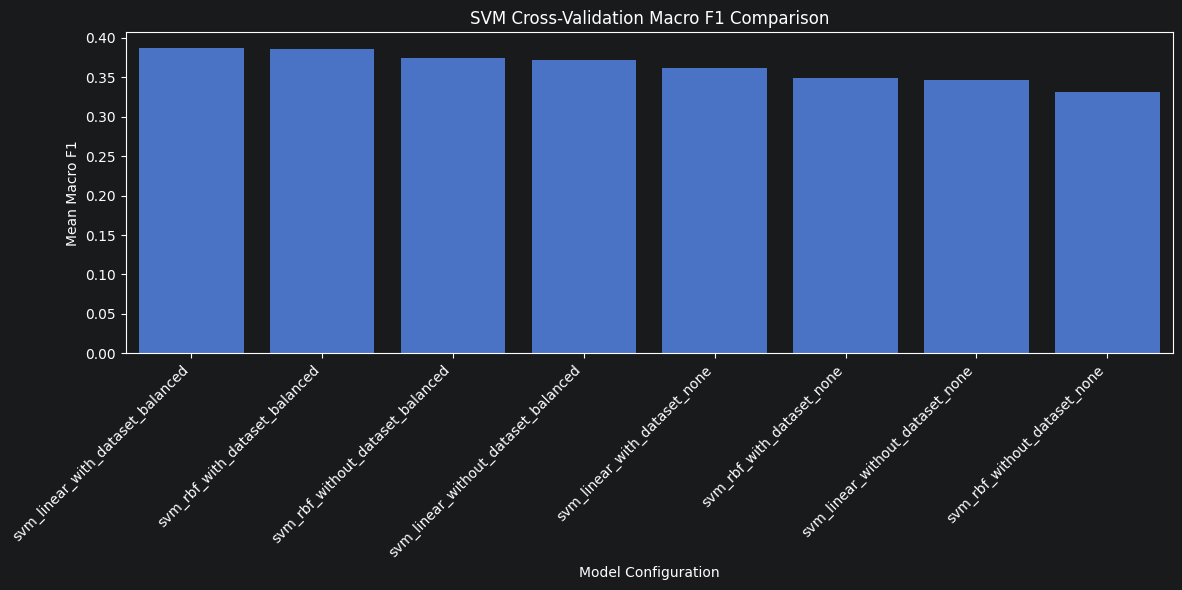

In [28]:
SHOW_SVM_PLOTS = True


plt.figure(figsize=(12, 6))

axis = sns.barplot(
    data=svm_cv_results,
    x="model_name",
    y="cv_macro_f1_mean",
)

plt.title("SVM Cross-Validation Macro F1 Comparison")
plt.xlabel("Model Configuration")
plt.ylabel("Mean Macro F1")
plt.xticks(
    rotation=45,
    ha="right",
)
plt.tight_layout()

svm_cv_figure_path = (
    FIGURES_DIR
    / "10_svm_cv_macro_f1_comparison.png"
)

plt.savefig(
    svm_cv_figure_path,
    dpi=200,
    bbox_inches="tight",
)

if SHOW_SVM_PLOTS:
    plt.show()

plt.close()

In [29]:
best_svm_configurations = (
    svm_cv_results
    .sort_values(
        by=[
            "kernel",
            "cv_macro_f1_mean",
            "cv_macro_recall_mean",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby(
        "kernel",
        as_index=False,
        group_keys=False,
    )
    .head(1)
    .reset_index(drop=True)
)


display(
    best_svm_configurations.round(4)
)

,model_name,kernel,dataset_mode,class_weight,C,gamma,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_macro_precision_mean,cv_macro_recall_mean,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,elapsed_seconds
0,svm_linear_with_dataset_balanced,linear,with_dataset,balanced,1.0,scale,0.5436,0.0467,0.3938,0.4016,0.3938,0.3876,0.0471,0.5645,0.3935
1,svm_rbf_with_dataset_balanced,rbf,with_dataset,balanced,1.0,scale,0.5531,0.0387,0.3974,0.3931,0.3974,0.3857,0.0277,0.5702,0.7672


In [30]:
def configuration_from_result_row(result_row):
    return {
        "kernel": result_row["kernel"],
        "dataset_mode": result_row[
            "dataset_mode"
        ],
        "class_weight_name": result_row[
            "class_weight"
        ],
        "class_weight": (
            None
            if result_row["class_weight"] == "none"
            else "balanced"
        ),
        "C": float(result_row["C"]),
        "gamma": result_row["gamma"],
    }

In [31]:
best_svm_models = {}
svm_test_predictions = {}
svm_test_rows = []
classification_report_frames = []


for result_row in best_svm_configurations.to_dict(
    orient="records"
):
    configuration = configuration_from_result_row(
        result_row
    )

    model_name = result_row["model_name"]

    X_train_candidate = (
        select_features_for_configuration(
            input_data=X_train,
            dataset_mode=configuration[
                "dataset_mode"
            ],
        )
    )

    X_test_candidate = (
        select_features_for_configuration(
            input_data=X_test,
            dataset_mode=configuration[
                "dataset_mode"
            ],
        )
    )

    model_pipeline = build_svm_pipeline(
        configuration=configuration
    )

    start_time = time.perf_counter()

    model_pipeline.fit(
        X_train_candidate,
        y_train,
    )

    training_seconds = (
        time.perf_counter() - start_time
    )

    start_time = time.perf_counter()

    predictions = model_pipeline.predict(
        X_test_candidate
    )

    prediction_seconds = (
        time.perf_counter() - start_time
    )

    best_svm_models[
        configuration["kernel"]
    ] = model_pipeline

    svm_test_predictions[
        configuration["kernel"]
    ] = predictions

    svm_test_rows.append(
        {
            "model_name": model_name,
            "kernel": configuration["kernel"],
            "dataset_mode": configuration[
                "dataset_mode"
            ],
            "class_weight": configuration[
                "class_weight_name"
            ],
            "accuracy": accuracy_score(
                y_test,
                predictions,
            ),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    y_test,
                    predictions,
                )
            ),
            "macro_precision": precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            ),
            "macro_recall": recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            ),
            "macro_f1": f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            ),
            "weighted_f1": f1_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0,
            ),
            "training_seconds": training_seconds,
            "prediction_seconds": (
                prediction_seconds
            ),
        }
    )

    report_dictionary = classification_report(
        y_test,
        predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "class_0",
            "class_1",
            "class_2",
            "class_3",
            "class_4",
        ],
        output_dict=True,
        zero_division=0,
    )

    report_frame = (
        pd.DataFrame(
            report_dictionary
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index": "report_row",
            }
        )
    )

    report_frame.insert(
        0,
        "model_name",
        model_name,
    )

    classification_report_frames.append(
        report_frame
    )

    print(f"Test evaluation completed: {model_name}")

Test evaluation completed: svm_linear_with_dataset_balanced
Test evaluation completed: svm_rbf_with_dataset_balanced


In [32]:
svm_test_results = pd.DataFrame(
    svm_test_rows
)


svm_test_results = svm_test_results.sort_values(
    by=[
        "macro_f1",
        "macro_recall",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)


svm_classification_reports = pd.concat(
    classification_report_frames,
    ignore_index=True,
)


display(
    svm_test_results.round(4)
)

,model_name,kernel,dataset_mode,class_weight,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds
0,svm_rbf_with_dataset_balanced,rbf,with_dataset,balanced,0.5380,0.4054,0.3998,0.4054,0.3918,0.5657,0.0829,0.0782
1,svm_linear_with_dataset_balanced,linear,with_dataset,balanced,0.5054,0.4453,0.3910,0.4453,0.3818,0.5364,0.0948,0.0237


In [33]:
for model_name in (
    svm_classification_reports[
        "model_name"
    ].unique()
):
    print(f"Classification report: {model_name}")

    display(
        svm_classification_reports[
            svm_classification_reports[
                "model_name"
            ]
            == model_name
        ].round(4)
    )

Classification report: svm_linear_with_dataset_balanced


,model_name,report_row,precision,recall,f1-score,support
0,svm_linear_with_dataset_balanced,class_0,0.8676,0.7195,0.7867,82.0000
1,svm_linear_with_dataset_balanced,class_1,0.5714,0.3774,0.4545,53.0000
2,svm_linear_with_dataset_balanced,class_2,0.1818,0.2727,0.2182,22.0000
3,svm_linear_with_dataset_balanced,class_3,0.1600,0.1905,0.1739,21.0000
4,svm_linear_with_dataset_balanced,class_4,0.1739,0.6667,0.2759,6.0000
5,svm_linear_with_dataset_balanced,accuracy,0.5054,0.5054,0.5054,0.5054
6,svm_linear_with_dataset_balanced,macro avg,0.3910,0.4453,0.3818,184.0000
7,svm_linear_with_dataset_balanced,weighted avg,0.5969,0.5054,0.5364,184.0000


Classification report: svm_rbf_with_dataset_balanced


,model_name,report_row,precision,recall,f1-score,support
8,svm_rbf_with_dataset_balanced,class_0,0.8841,0.7439,0.8079,82.000
9,svm_rbf_with_dataset_balanced,class_1,0.5641,0.4151,0.4783,53.000
10,svm_rbf_with_dataset_balanced,class_2,0.1935,0.2727,0.2264,22.000
11,svm_rbf_with_dataset_balanced,class_3,0.2571,0.4286,0.3214,21.000
12,svm_rbf_with_dataset_balanced,class_4,0.1000,0.1667,0.1250,6.000
13,svm_rbf_with_dataset_balanced,accuracy,0.5380,0.5380,0.5380,0.538
14,svm_rbf_with_dataset_balanced,macro avg,0.3998,0.4054,0.3918,184.000
15,svm_rbf_with_dataset_balanced,weighted avg,0.6122,0.5380,0.5657,184.000


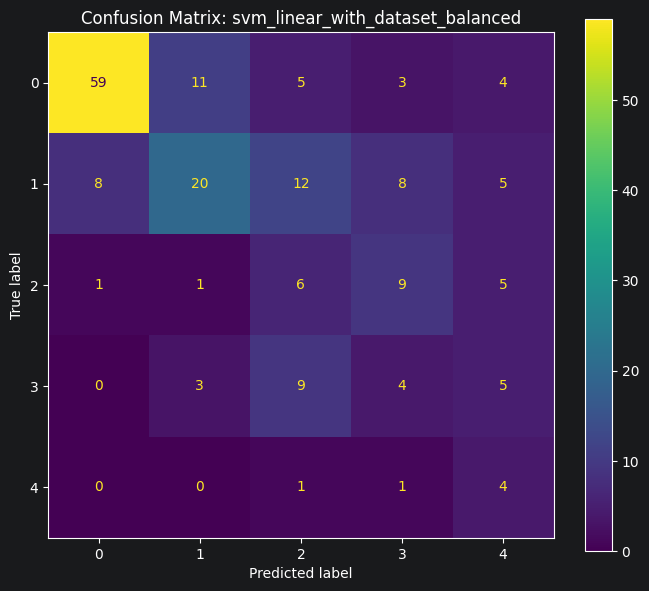

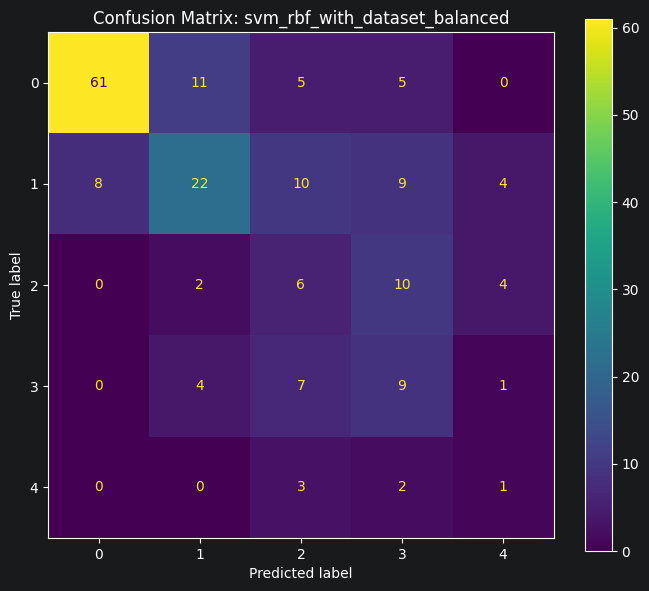

In [34]:
for kernel_name in ["linear", "rbf"]:
    model_result = svm_test_results[
        svm_test_results["kernel"]
        == kernel_name
    ].iloc[0]

    model_name = model_result["model_name"]

    predictions = svm_test_predictions[
        kernel_name
    ]

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=predictions,
        labels=[0, 1, 2, 3, 4],
        display_labels=[0, 1, 2, 3, 4],
        values_format="d",
        ax=axis,
    )

    axis.set_title(
        f"Confusion Matrix: {model_name}"
    )

    figure.tight_layout()

    confusion_matrix_path = (
        FIGURES_DIR
        / f"10_svm_{kernel_name}_confusion_matrix.png"
    )

    figure.savefig(
        confusion_matrix_path,
        dpi=200,
        bbox_inches="tight",
    )

    if SHOW_SVM_PLOTS:
        plt.show()

    plt.close(figure)

In [35]:
svm_predictions_table = pd.DataFrame(
    {
        "row_index": X_test.index,
        "record_id": df_raw.loc[
            X_test.index,
            "id",
        ].to_numpy(),
        "actual_class": y_test.to_numpy(),
        "linear_prediction": (
            svm_test_predictions["linear"]
        ),
        "rbf_prediction": (
            svm_test_predictions["rbf"]
        ),
    }
)


svm_predictions_table[
    "linear_is_correct"
] = (
    svm_predictions_table[
        "linear_prediction"
    ]
    == svm_predictions_table[
        "actual_class"
    ]
)


svm_predictions_table[
    "rbf_is_correct"
] = (
    svm_predictions_table[
        "rbf_prediction"
    ]
    == svm_predictions_table[
        "actual_class"
    ]
)


display(
    svm_predictions_table.head()
)

,row_index,record_id,actual_class,linear_prediction,rbf_prediction,linear_is_correct,rbf_is_correct
0,529,530,1,1,1,True,True
1,683,684,3,2,3,False,True
2,919,920,1,3,3,False,False
3,146,147,4,4,3,True,False
4,887,888,0,0,3,True,False


In [36]:
linear_model_path = (
    MODELS_DIR
    / "10_best_linear_svm.joblib"
)

rbf_model_path = (
    MODELS_DIR
    / "10_best_rbf_svm.joblib"
)


joblib.dump(
    best_svm_models["linear"],
    linear_model_path,
)

joblib.dump(
    best_svm_models["rbf"],
    rbf_model_path,
)


print("SVM models saved successfully.")
print(linear_model_path)
print(rbf_model_path)

SVM models saved successfully.
E:\Projects\DataMining\outputs\models\10_best_linear_svm.joblib
E:\Projects\DataMining\outputs\models\10_best_rbf_svm.joblib


In [37]:
svm_configuration_table.to_csv(
    TABLES_DIR
    / "10_svm_configurations.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_cv_results.to_csv(
    TABLES_DIR
    / "10_svm_cv_results.csv",
    index=False,
    encoding="utf-8-sig",
)

best_svm_configurations.to_csv(
    TABLES_DIR
    / "10_svm_best_configurations.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_test_results.to_csv(
    TABLES_DIR
    / "10_svm_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_classification_reports.to_csv(
    TABLES_DIR
    / "10_svm_classification_reports.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_predictions_table.to_csv(
    TABLES_DIR
    / "10_svm_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 10 tables saved successfully.")

Stage 10 tables saved successfully.


In [38]:
assert len(svm_cv_results) == 8, (
    "The SVM cross-validation table must contain eight models."
)

assert set(
    svm_cv_results["kernel"]
) == {
    "linear",
    "rbf",
}, (
    "Both linear and RBF kernels must be evaluated."
)

assert set(
    svm_cv_results["dataset_mode"]
) == {
    "with_dataset",
    "without_dataset",
}, (
    "Both dataset-feature configurations must be evaluated."
)

assert set(
    svm_cv_results["class_weight"]
) == {
    "none",
    "balanced",
}, (
    "Both class-weight configurations must be evaluated."
)

assert len(best_svm_configurations) == 2, (
    "One best configuration must be selected for each kernel."
)

assert len(svm_test_results) == 2, (
    "Two SVM models must be evaluated on the test set."
)

evaluation_metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]


evaluation_metrics = svm_test_results[
    evaluation_metric_columns
]


assert (
    (
        (evaluation_metrics >= 0)
        & (evaluation_metrics <= 1)
    )
    .all()
    .all()
), (
    "All evaluation metrics must be between zero and one."
)

assert len(svm_predictions_table) == len(y_test), (
    "The prediction table must contain every test row."
)

assert (
    svm_predictions_table[
        "actual_class"
    ]
    .isin([0, 1, 2, 3, 4])
    .all()
), (
    "Unexpected target classes were detected."
)

assert set(best_svm_models.keys()) == {
    "linear",
    "rbf",
}, (
    "Both selected SVM models must be available."
)


required_output_files = [
    TABLES_DIR / "10_svm_configurations.csv",
    TABLES_DIR / "10_svm_cv_results.csv",
    TABLES_DIR / "10_svm_best_configurations.csv",
    TABLES_DIR / "10_svm_test_results.csv",
    TABLES_DIR
    / "10_svm_classification_reports.csv",
    TABLES_DIR / "10_svm_test_predictions.csv",
    FIGURES_DIR
    / "10_svm_cv_macro_f1_comparison.png",
    FIGURES_DIR
    / "10_svm_linear_confusion_matrix.png",
    FIGURES_DIR
    / "10_svm_rbf_confusion_matrix.png",
    linear_model_path,
    rbf_model_path,
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 10 validation checks passed.")

All Stage 10 validation checks passed.


## Stage 11: K-Nearest Neighbors Classification

This stage evaluates K-Nearest Neighbors classifiers using three
different neighborhood sizes.

Each neighborhood size is tested with and without the dataset source
feature. Configurations are compared using stratified cross-validation
on the training data.

The best configuration is then evaluated once on the test set.

In [39]:
REQUIRED_STAGE_9_OBJECTS = [
    "df_raw",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES_WITH_DATASET",
    "CATEGORICAL_FEATURES_WITHOUT_DATASET",
    "FEATURES_WITH_DATASET",
    "FEATURES_WITHOUT_DATASET",
    "build_preprocessor",
    "TABLES_DIR",
    "MODELS_DIR",
    "PROJECT_ROOT",
]


missing_stage_9_objects = [
    object_name
    for object_name in REQUIRED_STAGE_9_OBJECTS
    if object_name not in globals()
]


if missing_stage_9_objects:
    raise RuntimeError(
        "Stage 9 must be executed before Stage 11.\n"
        f"Missing objects: {missing_stage_9_objects}"
    )


print("Stage 9 dependencies are available.")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Stage 9 dependencies are available.
Training rows: 736
Test rows: 184


In [40]:
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline


FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2, 3, 4]


cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_precision": make_scorer(
        precision_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": make_scorer(
        recall_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="weighted",
        zero_division=0,
    ),
}


print("KNN libraries and evaluation settings are ready.")
print(f"Number of folds: {cross_validation.get_n_splits()}")

KNN libraries and evaluation settings are ready.
Number of folds: 5


In [41]:
K_VALUES = [3, 5, 7]


KNN_CONFIGURATIONS = []


for k_value in K_VALUES:
    for dataset_mode in [
        "with_dataset",
        "without_dataset",
    ]:
        KNN_CONFIGURATIONS.append(
            {
                "n_neighbors": k_value,
                "dataset_mode": dataset_mode,
                "weights": "uniform",
                "metric": "minkowski",
                "p": 2,
            }
        )


knn_configuration_table = pd.DataFrame(
    KNN_CONFIGURATIONS
)


display(knn_configuration_table)

,n_neighbors,dataset_mode,weights,metric,p
0,3,with_dataset,uniform,minkowski,2
1,3,without_dataset,uniform,minkowski,2
2,5,with_dataset,uniform,minkowski,2
3,5,without_dataset,uniform,minkowski,2
4,7,with_dataset,uniform,minkowski,2
5,7,without_dataset,uniform,minkowski,2


In [42]:
def select_knn_features(
    input_data,
    dataset_mode,
):
    if dataset_mode == "with_dataset":
        return input_data[
            FEATURES_WITH_DATASET
        ].copy()

    if dataset_mode == "without_dataset":
        return input_data[
            FEATURES_WITHOUT_DATASET
        ].copy()

    raise ValueError(
        "Dataset mode must be "
        "'with_dataset' or 'without_dataset'."
    )

In [43]:
def build_knn_pipeline(configuration):
    if configuration["dataset_mode"] == "with_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITH_DATASET
        )
    elif configuration["dataset_mode"] == "without_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITHOUT_DATASET
        )
    else:
        raise ValueError(
            "Dataset mode must be "
            "'with_dataset' or 'without_dataset'."
        )

    preprocessor = build_preprocessor(
        numeric_features=NUMERIC_FEATURES,
        categorical_features=categorical_features,
        numeric_imputation_strategy="median",
        scaler_name="standard",
    )

    classifier = KNeighborsClassifier(
        n_neighbors=configuration[
            "n_neighbors"
        ],
        weights=configuration["weights"],
        metric=configuration["metric"],
        p=configuration["p"],
        n_jobs=1,
    )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    return model_pipeline

In [44]:
knn_cv_rows = []


for configuration in KNN_CONFIGURATIONS:
    model_name = (
        f"knn_k{configuration['n_neighbors']}_"
        f"{configuration['dataset_mode']}"
    )

    X_train_candidate = select_knn_features(
        input_data=X_train,
        dataset_mode=configuration[
            "dataset_mode"
        ],
    )

    model_pipeline = build_knn_pipeline(
        configuration=configuration
    )

    start_time = time.perf_counter()

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_train_candidate,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    knn_cv_rows.append(
        {
            "model_name": model_name,
            "n_neighbors": configuration[
                "n_neighbors"
            ],
            "dataset_mode": configuration[
                "dataset_mode"
            ],
            "weights": configuration["weights"],
            "cv_accuracy_mean": (
                cv_result["test_accuracy"].mean()
            ),
            "cv_accuracy_std": (
                cv_result["test_accuracy"].std()
            ),
            "cv_balanced_accuracy_mean": (
                cv_result[
                    "test_balanced_accuracy"
                ].mean()
            ),
            "cv_macro_precision_mean": (
                cv_result[
                    "test_macro_precision"
                ].mean()
            ),
            "cv_macro_recall_mean": (
                cv_result[
                    "test_macro_recall"
                ].mean()
            ),
            "cv_macro_f1_mean": (
                cv_result[
                    "test_macro_f1"
                ].mean()
            ),
            "cv_macro_f1_std": (
                cv_result[
                    "test_macro_f1"
                ].std()
            ),
            "cv_weighted_f1_mean": (
                cv_result[
                    "test_weighted_f1"
                ].mean()
            ),
            "elapsed_seconds": elapsed_seconds,
        }
    )

    print(f"Completed: {model_name}")

Completed: knn_k3_with_dataset
Completed: knn_k3_without_dataset
Completed: knn_k5_with_dataset
Completed: knn_k5_without_dataset
Completed: knn_k7_with_dataset
Completed: knn_k7_without_dataset


In [45]:
knn_cv_results = pd.DataFrame(
    knn_cv_rows
)


knn_cv_results = knn_cv_results.sort_values(
    by=[
        "cv_macro_f1_mean",
        "cv_macro_recall_mean",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)


display(
    knn_cv_results.round(4)
)

,model_name,n_neighbors,dataset_mode,weights,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_macro_precision_mean,cv_macro_recall_mean,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,elapsed_seconds
0,knn_k5_with_dataset,5,with_dataset,uniform,0.5693,0.0211,0.3628,0.3896,0.3628,0.3613,0.0305,0.5441,0.6328
1,knn_k3_with_dataset,3,with_dataset,uniform,0.5585,0.0337,0.3408,0.3398,0.3408,0.3331,0.0347,0.5250,0.8124
2,knn_k5_without_dataset,5,without_dataset,uniform,0.5639,0.0353,0.3385,0.3533,0.3385,0.3319,0.0307,0.5318,0.7082
3,knn_k7_without_dataset,7,without_dataset,uniform,0.5680,0.0365,0.3360,0.3693,0.3360,0.3313,0.0362,0.5298,0.5030
4,knn_k7_with_dataset,7,with_dataset,uniform,0.5599,0.0456,0.3344,0.3431,0.3344,0.3286,0.0313,0.5293,0.5519
5,knn_k3_without_dataset,3,without_dataset,uniform,0.5435,0.0359,0.3214,0.3398,0.3214,0.3157,0.0435,0.5059,0.5541


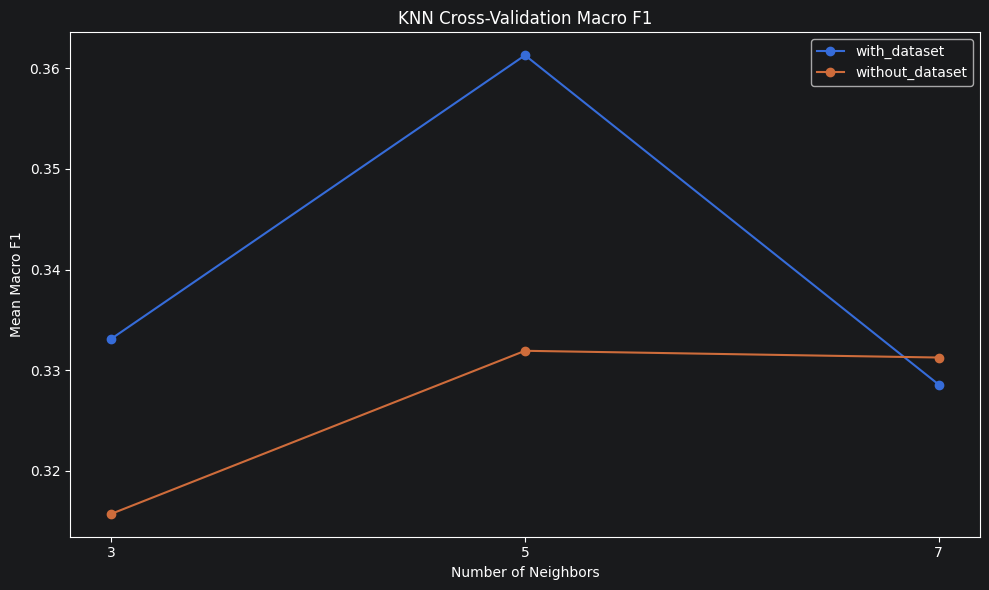

In [46]:
SHOW_KNN_PLOTS = True


plt.figure(figsize=(10, 6))


for dataset_mode in [
    "with_dataset",
    "without_dataset",
]:
    mode_results = knn_cv_results[
        knn_cv_results["dataset_mode"]
        == dataset_mode
    ].sort_values(
        by="n_neighbors"
    )

    plt.plot(
        mode_results["n_neighbors"],
        mode_results["cv_macro_f1_mean"],
        marker="o",
        label=dataset_mode,
    )


plt.title("KNN Cross-Validation Macro F1")
plt.xlabel("Number of Neighbors")
plt.ylabel("Mean Macro F1")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()


knn_cv_figure_path = (
    FIGURES_DIR
    / "11_knn_cv_macro_f1_comparison.png"
)


plt.savefig(
    knn_cv_figure_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_KNN_PLOTS:
    plt.show()


plt.close()

In [47]:
best_knn_result = (
    knn_cv_results.iloc[0]
)


best_knn_configuration = {
    "n_neighbors": int(
        best_knn_result["n_neighbors"]
    ),
    "dataset_mode": best_knn_result[
        "dataset_mode"
    ],
    "weights": best_knn_result["weights"],
    "metric": "minkowski",
    "p": 2,
}


best_knn_configuration_table = pd.DataFrame(
    [best_knn_configuration]
)


display(best_knn_configuration_table)

,n_neighbors,dataset_mode,weights,metric,p
0,5,with_dataset,uniform,minkowski,2


In [48]:
X_train_best_knn = select_knn_features(
    input_data=X_train,
    dataset_mode=best_knn_configuration[
        "dataset_mode"
    ],
)


X_test_best_knn = select_knn_features(
    input_data=X_test,
    dataset_mode=best_knn_configuration[
        "dataset_mode"
    ],
)


best_knn_model = build_knn_pipeline(
    configuration=best_knn_configuration
)


start_time = time.perf_counter()


best_knn_model.fit(
    X_train_best_knn,
    y_train,
)


training_seconds = (
    time.perf_counter() - start_time
)


start_time = time.perf_counter()


knn_test_predictions = best_knn_model.predict(
    X_test_best_knn
)


prediction_seconds = (
    time.perf_counter() - start_time
)


knn_test_results = pd.DataFrame(
    [
        {
            "model_name": (
                f"knn_k"
                f"{best_knn_configuration['n_neighbors']}_"
                f"{best_knn_configuration['dataset_mode']}"
            ),
            "n_neighbors": (
                best_knn_configuration[
                    "n_neighbors"
                ]
            ),
            "dataset_mode": (
                best_knn_configuration[
                    "dataset_mode"
                ]
            ),
            "accuracy": accuracy_score(
                y_test,
                knn_test_predictions,
            ),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    y_test,
                    knn_test_predictions,
                )
            ),
            "macro_precision": precision_score(
                y_test,
                knn_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "macro_recall": recall_score(
                y_test,
                knn_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "macro_f1": f1_score(
                y_test,
                knn_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "weighted_f1": f1_score(
                y_test,
                knn_test_predictions,
                labels=CLASS_LABELS,
                average="weighted",
                zero_division=0,
            ),
            "training_seconds": training_seconds,
            "prediction_seconds": prediction_seconds,
        }
    ]
)


display(
    knn_test_results.round(4)
)

,model_name,n_neighbors,dataset_mode,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds
0,knn_k5_with_dataset,5,with_dataset,0.5924,0.3997,0.5665,0.3997,0.4172,0.5782,0.0614,0.1222


In [49]:
knn_classification_report = (
    pd.DataFrame(
        classification_report(
            y_test,
            knn_test_predictions,
            labels=CLASS_LABELS,
            target_names=[
                "class_0",
                "class_1",
                "class_2",
                "class_3",
                "class_4",
            ],
            output_dict=True,
            zero_division=0,
        )
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "report_row",
        }
    )
)


display(
    knn_classification_report.round(4)
)

,report_row,precision,recall,f1-score,support
0,class_0,0.8101,0.7805,0.7950,82.0000
1,class_1,0.4865,0.6792,0.5669,53.0000
2,class_2,0.2857,0.1818,0.2222,22.0000
3,class_3,0.2500,0.1905,0.2162,21.0000
4,class_4,1.0000,0.1667,0.2857,6.0000
5,accuracy,0.5924,0.5924,0.5924,0.5924
6,macro avg,0.5665,0.3997,0.4172,184.0000
7,weighted avg,0.5965,0.5924,0.5782,184.0000


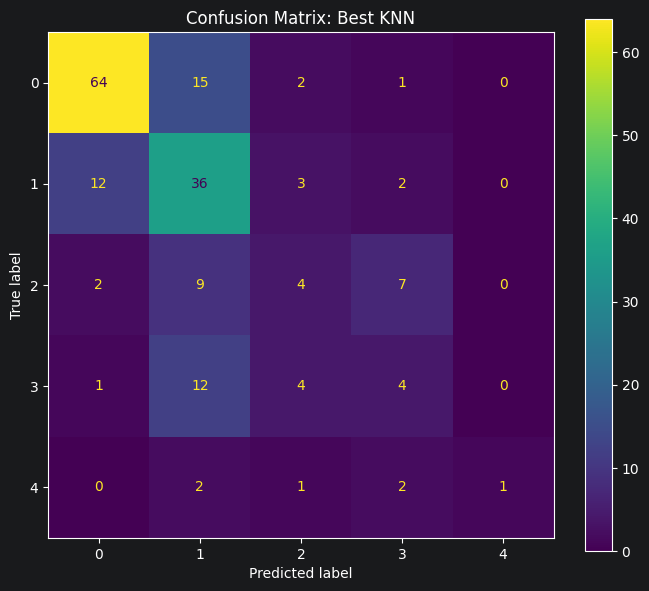

In [50]:
figure, axis = plt.subplots(
    figsize=(7, 6)
)


ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=knn_test_predictions,
    labels=CLASS_LABELS,
    display_labels=CLASS_LABELS,
    values_format="d",
    ax=axis,
)


axis.set_title(
    "Confusion Matrix: Best KNN"
)


figure.tight_layout()


knn_confusion_matrix_path = (
    FIGURES_DIR
    / "11_knn_confusion_matrix.png"
)


figure.savefig(
    knn_confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_KNN_PLOTS:
    plt.show()


plt.close(figure)

In [51]:
knn_predictions_table = pd.DataFrame(
    {
        "row_index": X_test.index,
        "record_id": df_raw.loc[
            X_test.index,
            "id",
        ].to_numpy(),
        "actual_class": y_test.to_numpy(),
        "predicted_class": knn_test_predictions,
    }
)


knn_predictions_table["is_correct"] = (
    knn_predictions_table["actual_class"]
    == knn_predictions_table["predicted_class"]
)


best_knn_model_path = (
    MODELS_DIR
    / "11_best_knn.joblib"
)


joblib.dump(
    best_knn_model,
    best_knn_model_path,
)


display(
    knn_predictions_table.head()
)


print("Best KNN model saved successfully.")
print(best_knn_model_path)

,row_index,record_id,actual_class,predicted_class,is_correct
0,529,530,1,1,True
1,683,684,3,1,False
2,919,920,1,3,False
3,146,147,4,4,True
4,887,888,0,1,False


Best KNN model saved successfully.
E:\Projects\DataMining\outputs\models\11_best_knn.joblib


In [52]:
knn_configuration_table.to_csv(
    TABLES_DIR / "11_knn_configurations.csv",
    index=False,
    encoding="utf-8-sig",
)


knn_cv_results.to_csv(
    TABLES_DIR / "11_knn_cv_results.csv",
    index=False,
    encoding="utf-8-sig",
)


best_knn_configuration_table.to_csv(
    TABLES_DIR
    / "11_knn_best_configuration.csv",
    index=False,
    encoding="utf-8-sig",
)


knn_test_results.to_csv(
    TABLES_DIR / "11_knn_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)


knn_classification_report.to_csv(
    TABLES_DIR
    / "11_knn_classification_report.csv",
    index=False,
    encoding="utf-8-sig",
)


knn_predictions_table.to_csv(
    TABLES_DIR
    / "11_knn_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 11 outputs saved successfully.")

Stage 11 outputs saved successfully.


In [53]:
assert len(knn_cv_results) == 6, (
    "The KNN cross-validation table must contain six models."
)


assert set(
    knn_cv_results["n_neighbors"]
) == {
    3,
    5,
    7,
}, (
    "The required neighbor values were not evaluated."
)


assert set(
    knn_cv_results["dataset_mode"]
) == {
    "with_dataset",
    "without_dataset",
}, (
    "Both dataset configurations must be evaluated."
)


assert len(knn_test_results) == 1, (
    "Exactly one selected KNN model must be tested."
)


evaluation_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]


evaluation_values = knn_test_results[
    evaluation_columns
]


assert (
    (
        (evaluation_values >= 0)
        & (evaluation_values <= 1)
    )
    .all()
    .all()
), (
    "All evaluation metrics must be between zero and one."
)


assert len(knn_predictions_table) == len(
    y_test
), (
    "The prediction table must contain every test row."
)


required_output_files = [
    TABLES_DIR / "11_knn_configurations.csv",
    TABLES_DIR / "11_knn_cv_results.csv",
    TABLES_DIR
    / "11_knn_best_configuration.csv",
    TABLES_DIR / "11_knn_test_results.csv",
    TABLES_DIR
    / "11_knn_classification_report.csv",
    TABLES_DIR
    / "11_knn_test_predictions.csv",
    FIGURES_DIR
    / "11_knn_cv_macro_f1_comparison.png",
    FIGURES_DIR
    / "11_knn_confusion_matrix.png",
    best_knn_model_path,
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 11 validation checks passed.")

All Stage 11 validation checks passed.


## Stage 12: Decision Tree Classification

This stage evaluates Decision Tree classifiers with different maximum
depths, class-weight configurations, and feature sets.

All configurations are compared using stratified cross-validation on
the training data. The best configuration is then fitted on the complete
training set and evaluated once on the test set.

Feature importance values are also extracted from the selected model.

In [54]:
REQUIRED_STAGE_9_OBJECTS = [
    "df_raw",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES_WITH_DATASET",
    "CATEGORICAL_FEATURES_WITHOUT_DATASET",
    "FEATURES_WITH_DATASET",
    "FEATURES_WITHOUT_DATASET",
    "build_preprocessor",
    "TABLES_DIR",
    "MODELS_DIR",
    "PROJECT_ROOT",
]


missing_stage_9_objects = [
    object_name
    for object_name in REQUIRED_STAGE_9_OBJECTS
    if object_name not in globals()
]


if missing_stage_9_objects:
    raise RuntimeError(
        "Stage 9 must be executed before Stage 12.\n"
        f"Missing objects: {missing_stage_9_objects}"
    )


print("Stage 9 dependencies are available.")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Stage 9 dependencies are available.
Training rows: 736
Test rows: 184


In [55]:
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2, 3, 4]


cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_precision": make_scorer(
        precision_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": make_scorer(
        recall_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="weighted",
        zero_division=0,
    ),
}


print("Decision Tree libraries and evaluation settings are ready.")
print(f"Number of folds: {cross_validation.get_n_splits()}")

Decision Tree libraries and evaluation settings are ready.
Number of folds: 5


In [56]:
MAX_DEPTH_VALUES = [
    3,
    5,
    None,
]


DECISION_TREE_CONFIGURATIONS = []


for max_depth_value in MAX_DEPTH_VALUES:
    for dataset_mode in [
        "with_dataset",
        "without_dataset",
    ]:
        for class_weight_name in [
            "none",
            "balanced",
        ]:
            DECISION_TREE_CONFIGURATIONS.append(
                {
                    "max_depth": max_depth_value,
                    "dataset_mode": dataset_mode,
                    "class_weight_name": class_weight_name,
                    "class_weight": (
                        None
                        if class_weight_name == "none"
                        else "balanced"
                    ),
                    "criterion": "gini",
                    "min_samples_split": 2,
                    "min_samples_leaf": 2,
                }
            )


decision_tree_configuration_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in configuration.items()
            if key != "class_weight"
        }
        for configuration in DECISION_TREE_CONFIGURATIONS
    ]
)


display(decision_tree_configuration_table)

,max_depth,dataset_mode,class_weight_name,criterion,min_samples_split,min_samples_leaf
0,3.0,with_dataset,none,gini,2,2
1,3.0,with_dataset,balanced,gini,2,2
2,3.0,without_dataset,none,gini,2,2
3,3.0,without_dataset,balanced,gini,2,2
4,5.0,with_dataset,none,gini,2,2
5,5.0,with_dataset,balanced,gini,2,2
6,5.0,without_dataset,none,gini,2,2
7,5.0,without_dataset,balanced,gini,2,2
8,NaN,with_dataset,none,gini,2,2
9,NaN,with_dataset,balanced,gini,2,2


In [57]:
def select_tree_features(
    input_data,
    dataset_mode,
):
    if dataset_mode == "with_dataset":
        return input_data[
            FEATURES_WITH_DATASET
        ].copy()

    if dataset_mode == "without_dataset":
        return input_data[
            FEATURES_WITHOUT_DATASET
        ].copy()

    raise ValueError(
        "Dataset mode must be "
        "'with_dataset' or 'without_dataset'."
    )

In [58]:
def build_decision_tree_pipeline(configuration):
    if configuration["dataset_mode"] == "with_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITH_DATASET
        )
    elif configuration["dataset_mode"] == "without_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITHOUT_DATASET
        )
    else:
        raise ValueError(
            "Dataset mode must be "
            "'with_dataset' or 'without_dataset'."
        )

    preprocessor = build_preprocessor(
        numeric_features=NUMERIC_FEATURES,
        categorical_features=categorical_features,
        numeric_imputation_strategy="median",
        scaler_name="standard",
    )

    classifier = DecisionTreeClassifier(
        criterion=configuration["criterion"],
        max_depth=configuration["max_depth"],
        min_samples_split=configuration[
            "min_samples_split"
        ],
        min_samples_leaf=configuration[
            "min_samples_leaf"
        ],
        class_weight=configuration["class_weight"],
        random_state=RANDOM_STATE,
    )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    return model_pipeline

In [59]:
decision_tree_cv_rows = []


for configuration in DECISION_TREE_CONFIGURATIONS:
    depth_name = (
        "none"
        if configuration["max_depth"] is None
        else str(configuration["max_depth"])
    )

    model_name = (
        f"decision_tree_depth_{depth_name}_"
        f"{configuration['dataset_mode']}_"
        f"{configuration['class_weight_name']}"
    )

    X_train_candidate = select_tree_features(
        input_data=X_train,
        dataset_mode=configuration[
            "dataset_mode"
        ],
    )

    model_pipeline = build_decision_tree_pipeline(
        configuration=configuration
    )

    start_time = time.perf_counter()

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_train_candidate,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=1,
        return_train_score=True,
        error_score="raise",
    )

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    decision_tree_cv_rows.append(
        {
            "model_name": model_name,
            "max_depth": configuration[
                "max_depth"
            ],
            "dataset_mode": configuration[
                "dataset_mode"
            ],
            "class_weight": configuration[
                "class_weight_name"
            ],
            "criterion": configuration[
                "criterion"
            ],
            "min_samples_leaf": configuration[
                "min_samples_leaf"
            ],
            "cv_accuracy_mean": (
                cv_result["test_accuracy"].mean()
            ),
            "cv_accuracy_std": (
                cv_result["test_accuracy"].std()
            ),
            "cv_balanced_accuracy_mean": (
                cv_result[
                    "test_balanced_accuracy"
                ].mean()
            ),
            "cv_macro_precision_mean": (
                cv_result[
                    "test_macro_precision"
                ].mean()
            ),
            "cv_macro_recall_mean": (
                cv_result[
                    "test_macro_recall"
                ].mean()
            ),
            "cv_macro_f1_mean": (
                cv_result[
                    "test_macro_f1"
                ].mean()
            ),
            "cv_macro_f1_std": (
                cv_result[
                    "test_macro_f1"
                ].std()
            ),
            "cv_weighted_f1_mean": (
                cv_result[
                    "test_weighted_f1"
                ].mean()
            ),
            "train_macro_f1_mean": (
                cv_result[
                    "train_macro_f1"
                ].mean()
            ),
            "elapsed_seconds": elapsed_seconds,
        }
    )

    print(f"Completed: {model_name}")

Completed: decision_tree_depth_3_with_dataset_none
Completed: decision_tree_depth_3_with_dataset_balanced
Completed: decision_tree_depth_3_without_dataset_none
Completed: decision_tree_depth_3_without_dataset_balanced
Completed: decision_tree_depth_5_with_dataset_none
Completed: decision_tree_depth_5_with_dataset_balanced
Completed: decision_tree_depth_5_without_dataset_none
Completed: decision_tree_depth_5_without_dataset_balanced
Completed: decision_tree_depth_none_with_dataset_none
Completed: decision_tree_depth_none_with_dataset_balanced
Completed: decision_tree_depth_none_without_dataset_none
Completed: decision_tree_depth_none_without_dataset_balanced


In [60]:
decision_tree_cv_results = pd.DataFrame(
    decision_tree_cv_rows
)


decision_tree_cv_results[
    "overfitting_gap"
] = (
    decision_tree_cv_results[
        "train_macro_f1_mean"
    ]
    - decision_tree_cv_results[
        "cv_macro_f1_mean"
    ]
)


decision_tree_cv_results = (
    decision_tree_cv_results
    .sort_values(
        by=[
            "cv_macro_f1_mean",
            "cv_macro_recall_mean",
            "overfitting_gap",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


display(
    decision_tree_cv_results.round(4)
)

,model_name,max_depth,dataset_mode,class_weight,criterion,min_samples_leaf,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_macro_precision_mean,cv_macro_recall_mean,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,train_macro_f1_mean,elapsed_seconds,overfitting_gap
0,decision_tree_depth_5_with_dataset_none,5.0,with_dataset,none,gini,2,0.5679,0.0215,0.3566,0.3669,0.3566,0.3462,0.0176,0.5464,0.4750,1.0816,0.1288
1,decision_tree_depth_3_with_dataset_balanced,3.0,with_dataset,balanced,gini,2,0.4620,0.0329,0.4154,0.3818,0.4154,0.3358,0.0482,0.4765,0.3740,1.2994,0.0382
2,decision_tree_depth_none_with_dataset_balanced,NaN,with_dataset,balanced,gini,2,0.4838,0.0281,0.3434,0.3368,0.3434,0.3349,0.0427,0.4983,0.8542,1.0686,0.5193
3,decision_tree_depth_5_with_dataset_balanced,5.0,with_dataset,balanced,gini,2,0.4390,0.0472,0.3410,0.3834,0.3410,0.3260,0.0460,0.4892,0.4763,1.3943,0.1503
4,decision_tree_depth_5_without_dataset_balanced,5.0,without_dataset,balanced,gini,2,0.4525,0.0348,0.3294,0.3438,0.3294,0.3154,0.0260,0.4760,0.4903,0.7261,0.1749
5,decision_tree_depth_none_with_dataset_none,NaN,with_dataset,none,gini,2,0.5083,0.0470,0.3127,0.3171,0.3127,0.3115,0.0301,0.4913,0.7836,0.7678,0.4721
6,decision_tree_depth_none_without_dataset_balanced,NaN,without_dataset,balanced,gini,2,0.4511,0.0176,0.3117,0.3177,0.3117,0.3104,0.0105,0.4729,0.8374,1.3205,0.5270
7,decision_tree_depth_none_without_dataset_none,NaN,without_dataset,none,gini,2,0.4960,0.0324,0.3121,0.3134,0.3121,0.3093,0.0272,0.4819,0.7850,0.9825,0.4758
8,decision_tree_depth_5_without_dataset_none,5.0,without_dataset,none,gini,2,0.5286,0.0423,0.3124,0.3030,0.3124,0.3010,0.0310,0.4996,0.4818,0.9617,0.1808
9,decision_tree_depth_3_without_dataset_none,3.0,without_dataset,none,gini,2,0.5395,0.0356,0.3147,0.3380,0.3147,0.2935,0.0168,0.4964,0.3389,0.7808,0.0454


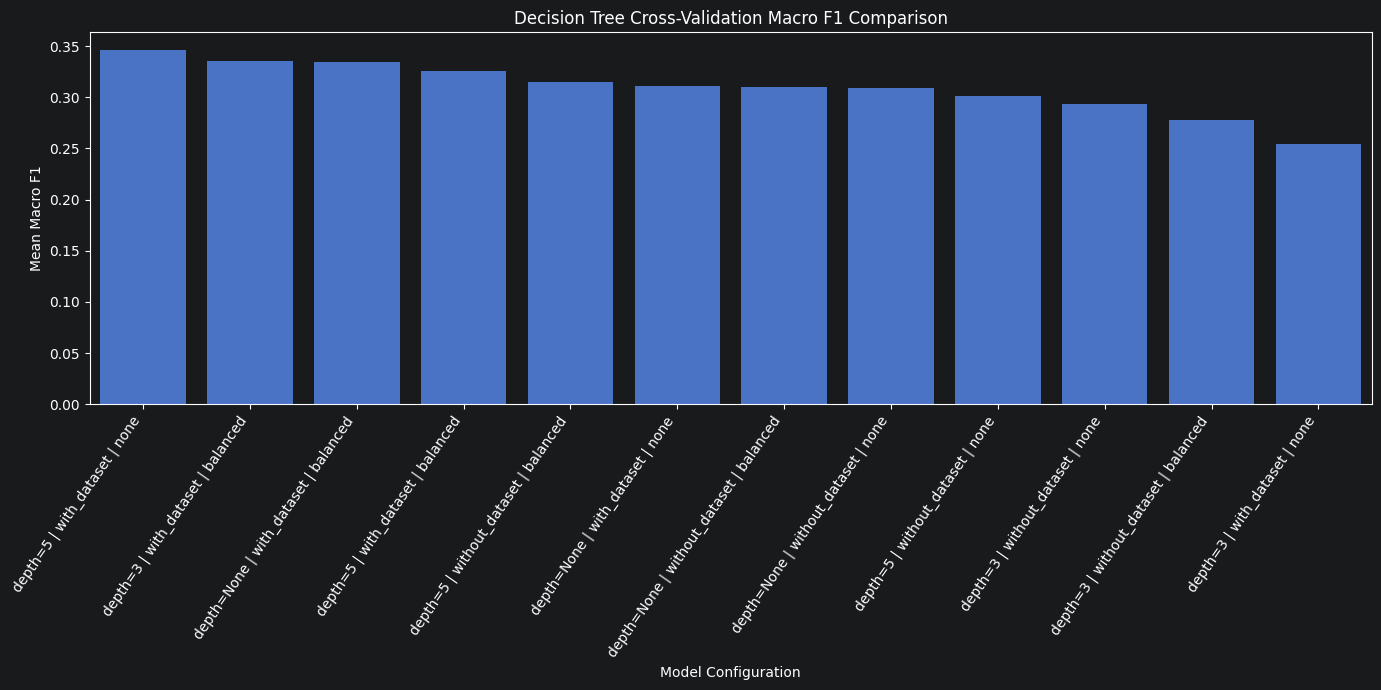

In [61]:
SHOW_TREE_PLOTS = True


plot_data = decision_tree_cv_results.copy()


plot_data["depth_label"] = (
    plot_data["max_depth"]
    .apply(
        lambda value: (
            "None"
            if pd.isna(value)
            else str(int(value))
        )
    )
)


plot_data["configuration_label"] = (
    "depth="
    + plot_data["depth_label"]
    + " | "
    + plot_data["dataset_mode"]
    + " | "
    + plot_data["class_weight"]
)


plt.figure(figsize=(14, 7))


sns.barplot(
    data=plot_data,
    x="configuration_label",
    y="cv_macro_f1_mean",
)


plt.title(
    "Decision Tree Cross-Validation Macro F1 Comparison"
)
plt.xlabel("Model Configuration")
plt.ylabel("Mean Macro F1")
plt.xticks(
    rotation=55,
    ha="right",
)
plt.tight_layout()


decision_tree_cv_figure_path = (
    FIGURES_DIR
    / "12_decision_tree_cv_macro_f1_comparison.png"
)


plt.savefig(
    decision_tree_cv_figure_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_TREE_PLOTS:
    plt.show()


plt.close()

In [62]:
best_decision_tree_result = (
    decision_tree_cv_results.iloc[0]
)


best_max_depth = (
    None
    if pd.isna(
        best_decision_tree_result[
            "max_depth"
        ]
    )
    else int(
        best_decision_tree_result[
            "max_depth"
        ]
    )
)


best_decision_tree_configuration = {
    "max_depth": best_max_depth,
    "dataset_mode": (
        best_decision_tree_result[
            "dataset_mode"
        ]
    ),
    "class_weight_name": (
        best_decision_tree_result[
            "class_weight"
        ]
    ),
    "class_weight": (
        None
        if best_decision_tree_result[
            "class_weight"
        ] == "none"
        else "balanced"
    ),
    "criterion": (
        best_decision_tree_result[
            "criterion"
        ]
    ),
    "min_samples_split": 2,
    "min_samples_leaf": int(
        best_decision_tree_result[
            "min_samples_leaf"
        ]
    ),
}


best_decision_tree_configuration_table = (
    pd.DataFrame(
        [
            {
                key: value
                for key, value
                in best_decision_tree_configuration.items()
                if key != "class_weight"
            }
        ]
    )
)


display(
    best_decision_tree_configuration_table
)

,max_depth,dataset_mode,class_weight_name,criterion,min_samples_split,min_samples_leaf
0,5,with_dataset,none,gini,2,2


In [63]:
X_train_best_tree = select_tree_features(
    input_data=X_train,
    dataset_mode=best_decision_tree_configuration[
        "dataset_mode"
    ],
)


X_test_best_tree = select_tree_features(
    input_data=X_test,
    dataset_mode=best_decision_tree_configuration[
        "dataset_mode"
    ],
)


best_decision_tree_model = (
    build_decision_tree_pipeline(
        configuration=(
            best_decision_tree_configuration
        )
    )
)


start_time = time.perf_counter()


best_decision_tree_model.fit(
    X_train_best_tree,
    y_train,
)


training_seconds = (
    time.perf_counter() - start_time
)


start_time = time.perf_counter()


decision_tree_test_predictions = (
    best_decision_tree_model.predict(
        X_test_best_tree
    )
)


prediction_seconds = (
    time.perf_counter() - start_time
)


print("Best Decision Tree model trained successfully.")

Best Decision Tree model trained successfully.


In [64]:
decision_tree_test_results = pd.DataFrame(
    [
        {
            "model_name": (
                best_decision_tree_result[
                    "model_name"
                ]
            ),
            "max_depth": best_max_depth,
            "dataset_mode": (
                best_decision_tree_configuration[
                    "dataset_mode"
                ]
            ),
            "class_weight": (
                best_decision_tree_configuration[
                    "class_weight_name"
                ]
            ),
            "accuracy": accuracy_score(
                y_test,
                decision_tree_test_predictions,
            ),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    y_test,
                    decision_tree_test_predictions,
                )
            ),
            "macro_precision": precision_score(
                y_test,
                decision_tree_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "macro_recall": recall_score(
                y_test,
                decision_tree_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "macro_f1": f1_score(
                y_test,
                decision_tree_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "weighted_f1": f1_score(
                y_test,
                decision_tree_test_predictions,
                labels=CLASS_LABELS,
                average="weighted",
                zero_division=0,
            ),
            "training_seconds": training_seconds,
            "prediction_seconds": prediction_seconds,
        }
    ]
)


display(
    decision_tree_test_results.round(4)
)

,model_name,max_depth,dataset_mode,class_weight,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds
0,decision_tree_depth_5_with_dataset_none,5,with_dataset,none,0.5598,0.3432,0.2964,0.3432,0.3155,0.5286,0.0543,0.0415


In [65]:
decision_tree_classification_report = (
    pd.DataFrame(
        classification_report(
            y_test,
            decision_tree_test_predictions,
            labels=CLASS_LABELS,
            target_names=[
                "class_0",
                "class_1",
                "class_2",
                "class_3",
                "class_4",
            ],
            output_dict=True,
            zero_division=0,
        )
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "report_row",
        }
    )
)


display(
    decision_tree_classification_report.round(4)
)

,report_row,precision,recall,f1-score,support
0,class_0,0.7848,0.7561,0.7702,82.0000
1,class_1,0.4474,0.6415,0.5271,53.0000
2,class_2,0.2500,0.3182,0.2800,22.0000
3,class_3,0.0000,0.0000,0.0000,21.0000
4,class_4,0.0000,0.0000,0.0000,6.0000
5,accuracy,0.5598,0.5598,0.5598,0.5598
6,macro avg,0.2964,0.3432,0.3155,184.0000
7,weighted avg,0.5085,0.5598,0.5286,184.0000


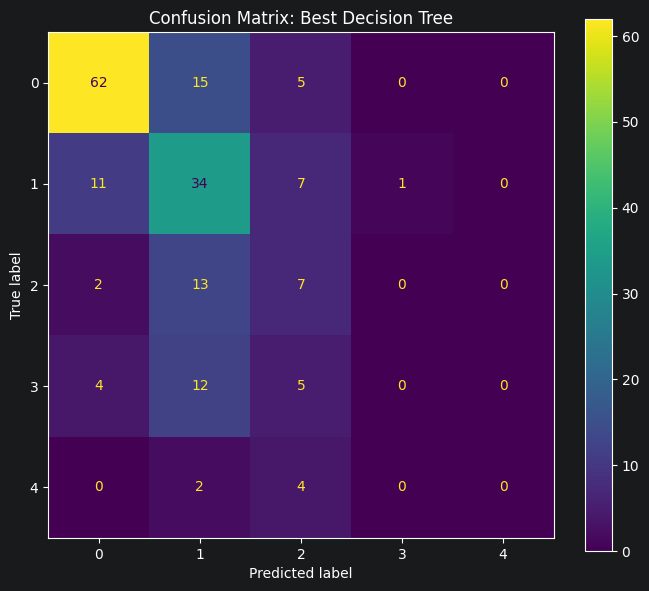

In [66]:
figure, axis = plt.subplots(
    figsize=(7, 6)
)


ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=decision_tree_test_predictions,
    labels=CLASS_LABELS,
    display_labels=CLASS_LABELS,
    values_format="d",
    ax=axis,
)


axis.set_title(
    "Confusion Matrix: Best Decision Tree"
)


figure.tight_layout()


decision_tree_confusion_matrix_path = (
    FIGURES_DIR
    / "12_decision_tree_confusion_matrix.png"
)


figure.savefig(
    decision_tree_confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_TREE_PLOTS:
    plt.show()


plt.close(figure)

In [67]:
fitted_preprocessor = (
    best_decision_tree_model.named_steps[
        "preprocessor"
    ]
)


fitted_classifier = (
    best_decision_tree_model.named_steps[
        "classifier"
    ]
)


transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)


feature_importance_table = pd.DataFrame(
    {
        "feature_name": transformed_feature_names,
        "importance": (
            fitted_classifier.feature_importances_
        ),
    }
)


feature_importance_table = (
    feature_importance_table
    .sort_values(
        by="importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


feature_importance_table[
    "importance_rank"
] = (
    feature_importance_table.index + 1
)


display(
    feature_importance_table.head(20).round(4)
)

,feature_name,importance,importance_rank
0,cp_asymptomatic,0.3206,1
1,oldpeak,0.1427,2
2,chol,0.0980,3
3,dataset_Hungary,0.0967,4
4,ca_0,0.0904,5
5,age,0.0660,6
6,thal_reversable defect,0.0659,7
7,thalch,0.0361,8
8,sex_Female,0.0251,9
9,trestbps,0.0216,10


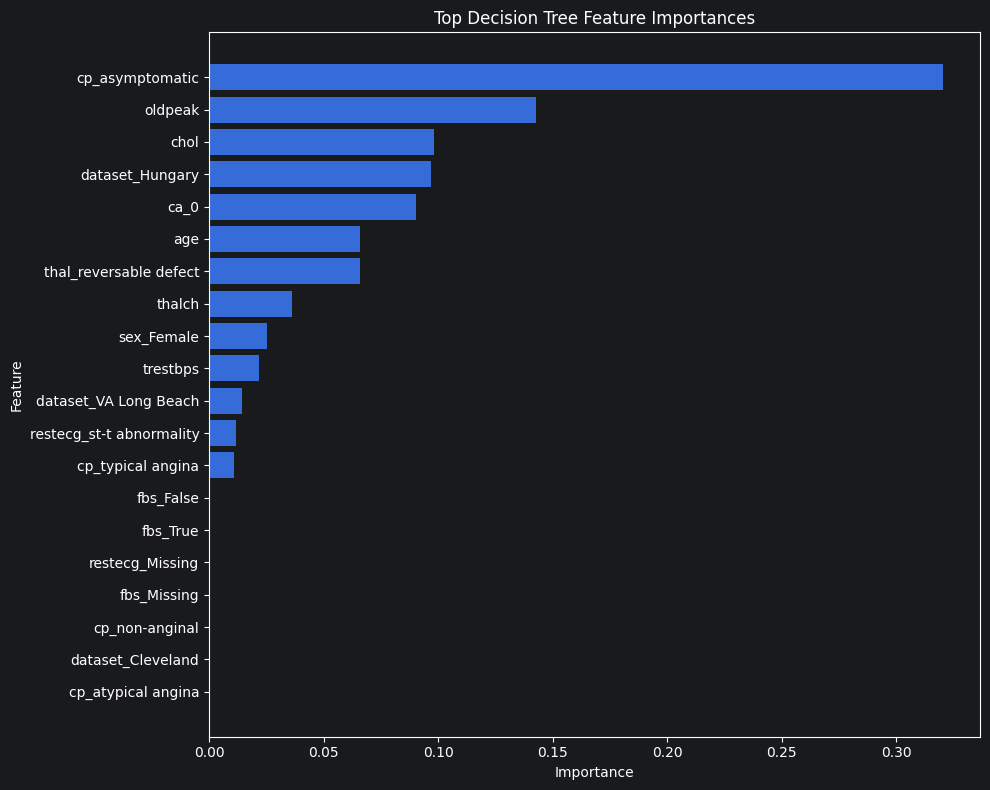

In [68]:
top_feature_importance = (
    feature_importance_table
    .head(20)
    .sort_values(
        by="importance",
        ascending=True,
    )
)


plt.figure(figsize=(10, 8))


plt.barh(
    top_feature_importance[
        "feature_name"
    ],
    top_feature_importance[
        "importance"
    ],
)


plt.title(
    "Top Decision Tree Feature Importances"
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()


feature_importance_figure_path = (
    FIGURES_DIR
    / "12_decision_tree_feature_importance.png"
)


plt.savefig(
    feature_importance_figure_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_TREE_PLOTS:
    plt.show()


plt.close()

In [69]:
decision_tree_predictions_table = pd.DataFrame(
    {
        "row_index": X_test.index,
        "record_id": df_raw.loc[
            X_test.index,
            "id",
        ].to_numpy(),
        "actual_class": y_test.to_numpy(),
        "predicted_class": (
            decision_tree_test_predictions
        ),
    }
)


decision_tree_predictions_table[
    "is_correct"
] = (
    decision_tree_predictions_table[
        "actual_class"
    ]
    == decision_tree_predictions_table[
        "predicted_class"
    ]
)


best_decision_tree_model_path = (
    MODELS_DIR
    / "12_best_decision_tree.joblib"
)


joblib.dump(
    best_decision_tree_model,
    best_decision_tree_model_path,
)


display(
    decision_tree_predictions_table.head()
)


print("Best Decision Tree model saved successfully.")
print(best_decision_tree_model_path)

,row_index,record_id,actual_class,predicted_class,is_correct
0,529,530,1,1,True
1,683,684,3,1,False
2,919,920,1,0,False
3,146,147,4,1,False
4,887,888,0,0,True


Best Decision Tree model saved successfully.
E:\Projects\DataMining\outputs\models\12_best_decision_tree.joblib


In [70]:
decision_tree_configuration_table.to_csv(
    TABLES_DIR
    / "12_decision_tree_configurations.csv",
    index=False,
    encoding="utf-8-sig",
)


decision_tree_cv_results.to_csv(
    TABLES_DIR
    / "12_decision_tree_cv_results.csv",
    index=False,
    encoding="utf-8-sig",
)


best_decision_tree_configuration_table.to_csv(
    TABLES_DIR
    / "12_decision_tree_best_configuration.csv",
    index=False,
    encoding="utf-8-sig",
)


decision_tree_test_results.to_csv(
    TABLES_DIR
    / "12_decision_tree_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)


decision_tree_classification_report.to_csv(
    TABLES_DIR
    / "12_decision_tree_classification_report.csv",
    index=False,
    encoding="utf-8-sig",
)


decision_tree_predictions_table.to_csv(
    TABLES_DIR
    / "12_decision_tree_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


feature_importance_table.to_csv(
    TABLES_DIR
    / "12_decision_tree_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 12 outputs saved successfully.")

Stage 12 outputs saved successfully.


In [71]:
assert len(decision_tree_cv_results) == 12, (
    "The cross-validation table must contain twelve models."
)


assert set(
    decision_tree_cv_results[
        "dataset_mode"
    ]
) == {
    "with_dataset",
    "without_dataset",
}, (
    "Both dataset configurations must be evaluated."
)


assert set(
    decision_tree_cv_results[
        "class_weight"
    ]
) == {
    "none",
    "balanced",
}, (
    "Both class-weight configurations must be evaluated."
)


assert len(
    decision_tree_test_results
) == 1, (
    "Exactly one selected Decision Tree model must be tested."
)


evaluation_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]


evaluation_values = (
    decision_tree_test_results[
        evaluation_columns
    ]
)


assert (
    (
        (evaluation_values >= 0)
        & (evaluation_values <= 1)
    )
    .all()
    .all()
), (
    "All evaluation metrics must be between zero and one."
)


assert len(
    decision_tree_predictions_table
) == len(y_test), (
    "The prediction table must contain every test row."
)


assert len(
    feature_importance_table
) == len(
    transformed_feature_names
), (
    "Feature names and importance values must match."
)


assert abs(
    feature_importance_table[
        "importance"
    ].sum() - 1.0
) < 1e-6, (
    "Feature importance values must sum to one."
)


required_output_files = [
    TABLES_DIR
    / "12_decision_tree_configurations.csv",
    TABLES_DIR
    / "12_decision_tree_cv_results.csv",
    TABLES_DIR
    / "12_decision_tree_best_configuration.csv",
    TABLES_DIR
    / "12_decision_tree_test_results.csv",
    TABLES_DIR
    / "12_decision_tree_classification_report.csv",
    TABLES_DIR
    / "12_decision_tree_test_predictions.csv",
    TABLES_DIR
    / "12_decision_tree_feature_importance.csv",
    FIGURES_DIR
    / "12_decision_tree_cv_macro_f1_comparison.png",
    FIGURES_DIR
    / "12_decision_tree_confusion_matrix.png",
    FIGURES_DIR
    / "12_decision_tree_feature_importance.png",
    best_decision_tree_model_path,
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 12 validation checks passed.")

All Stage 12 validation checks passed.


## Stage 13: Final Model and Preprocessing Comparison

This stage combines the test results of Linear SVM, RBF SVM, KNN,
and Decision Tree models.

Preprocessing alternatives are also compared using cross-validation
on the training set. The comparison includes mean versus median
imputation and StandardScaler versus MinMaxScaler.

The selected preprocessing configuration is evaluated once on the
test set, and a final model recommendation is produced.

In [72]:
REQUIRED_STAGE_9_OBJECTS = [
    "df_raw",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES_WITH_DATASET",
    "CATEGORICAL_FEATURES_WITHOUT_DATASET",
    "FEATURES_WITH_DATASET",
    "FEATURES_WITHOUT_DATASET",
    "build_preprocessor",
    "TABLES_DIR",
    "MODELS_DIR",
    "PROJECT_ROOT",
]


missing_stage_9_objects = [
    object_name
    for object_name in REQUIRED_STAGE_9_OBJECTS
    if object_name not in globals()
]


if missing_stage_9_objects:
    raise RuntimeError(
        "Stage 9 must be executed before Stage 13.\n"
        f"Missing objects: {missing_stage_9_objects}"
    )


REQUIRED_RESULT_FILES = [
    TABLES_DIR / "10_svm_cv_results.csv",
    TABLES_DIR / "10_svm_test_results.csv",
    TABLES_DIR / "10_svm_classification_reports.csv",
    TABLES_DIR / "11_knn_cv_results.csv",
    TABLES_DIR / "11_knn_test_results.csv",
    TABLES_DIR / "11_knn_classification_report.csv",
    TABLES_DIR / "12_decision_tree_cv_results.csv",
    TABLES_DIR / "12_decision_tree_test_results.csv",
    TABLES_DIR / "12_decision_tree_classification_report.csv",
]


missing_result_files = [
    str(file_path)
    for file_path in REQUIRED_RESULT_FILES
    if not file_path.exists()
]


if missing_result_files:
    raise FileNotFoundError(
        "Required result files are missing:\n"
        + "\n".join(missing_result_files)
    )


print("Stage 13 dependencies are available.")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Stage 13 dependencies are available.
Training rows: 736
Test rows: 184


In [73]:
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
)
from sklearn.svm import SVC


FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2, 3, 4]


cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_precision": make_scorer(
        precision_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_recall": make_scorer(
        recall_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": make_scorer(
        f1_score,
        labels=CLASS_LABELS,
        average="weighted",
        zero_division=0,
    ),
}


print("Stage 13 libraries and evaluation settings are ready.")

Stage 13 libraries and evaluation settings are ready.


In [74]:
svm_cv_results = pd.read_csv(
    TABLES_DIR / "10_svm_cv_results.csv"
)


svm_test_results = pd.read_csv(
    TABLES_DIR / "10_svm_test_results.csv"
)


svm_classification_reports = pd.read_csv(
    TABLES_DIR
    / "10_svm_classification_reports.csv"
)


knn_cv_results = pd.read_csv(
    TABLES_DIR / "11_knn_cv_results.csv"
)


knn_test_results = pd.read_csv(
    TABLES_DIR / "11_knn_test_results.csv"
)


knn_classification_report = pd.read_csv(
    TABLES_DIR
    / "11_knn_classification_report.csv"
)


decision_tree_cv_results = pd.read_csv(
    TABLES_DIR
    / "12_decision_tree_cv_results.csv"
)


decision_tree_test_results = pd.read_csv(
    TABLES_DIR
    / "12_decision_tree_test_results.csv"
)


decision_tree_classification_report = pd.read_csv(
    TABLES_DIR
    / "12_decision_tree_classification_report.csv"
)


print("Previous model results loaded successfully.")

Previous model results loaded successfully.


In [75]:
svm_comparison = svm_test_results.copy()


svm_comparison["algorithm"] = svm_comparison[
    "kernel"
].map(
    {
        "linear": "Linear SVM",
        "rbf": "RBF SVM",
    }
)


svm_comparison["model_detail"] = (
    "kernel="
    + svm_comparison["kernel"].astype(str)
    + " | dataset="
    + svm_comparison["dataset_mode"].astype(str)
    + " | class_weight="
    + svm_comparison["class_weight"].astype(str)
)


knn_comparison = knn_test_results.copy()


knn_comparison["algorithm"] = "KNN"


knn_comparison["model_detail"] = (
    "k="
    + knn_comparison["n_neighbors"]
    .astype(int)
    .astype(str)
    + " | dataset="
    + knn_comparison["dataset_mode"].astype(str)
)


decision_tree_comparison = (
    decision_tree_test_results.copy()
)


decision_tree_comparison["algorithm"] = (
    "Decision Tree"
)


decision_tree_comparison["model_detail"] = (
    "depth="
    + decision_tree_comparison[
        "max_depth"
    ].astype(str)
    + " | dataset="
    + decision_tree_comparison[
        "dataset_mode"
    ].astype(str)
    + " | class_weight="
    + decision_tree_comparison[
        "class_weight"
    ].astype(str)
)


comparison_columns = [
    "model_name",
    "algorithm",
    "model_detail",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "training_seconds",
    "prediction_seconds",
]


final_model_comparison = pd.concat(
    [
        svm_comparison[comparison_columns],
        knn_comparison[comparison_columns],
        decision_tree_comparison[
            comparison_columns
        ],
    ],
    ignore_index=True,
)

In [76]:
svm_class_4_recall = (
    svm_classification_reports[
        svm_classification_reports[
            "report_row"
        ] == "class_4"
    ][
        [
            "model_name",
            "recall",
        ]
    ]
    .rename(
        columns={
            "recall": "class_4_recall",
        }
    )
)


final_model_comparison = (
    final_model_comparison.merge(
        svm_class_4_recall,
        on="model_name",
        how="left",
    )
)


knn_class_4_recall = float(
    knn_classification_report.loc[
        knn_classification_report[
            "report_row"
        ] == "class_4",
        "recall",
    ].iloc[0]
)


tree_class_4_recall = float(
    decision_tree_classification_report.loc[
        decision_tree_classification_report[
            "report_row"
        ] == "class_4",
        "recall",
    ].iloc[0]
)


final_model_comparison.loc[
    final_model_comparison[
        "algorithm"
    ] == "KNN",
    "class_4_recall",
] = knn_class_4_recall


final_model_comparison.loc[
    final_model_comparison[
        "algorithm"
    ] == "Decision Tree",
    "class_4_recall",
] = tree_class_4_recall


final_model_comparison = (
    final_model_comparison
    .sort_values(
        by=[
            "macro_f1",
            "class_4_recall",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


display(
    final_model_comparison.round(4)
)

,model_name,algorithm,model_detail,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds,class_4_recall
0,knn_k5_with_dataset,KNN,k=5 | dataset=with_dataset,0.5924,0.3997,0.5665,0.3997,0.4172,0.5782,0.0614,0.1222,0.1667
1,svm_rbf_with_dataset_balanced,RBF SVM,kernel=rbf | dataset=with_dataset | class_weig...,0.5380,0.4054,0.3998,0.4054,0.3918,0.5657,0.0829,0.0782,0.1667
2,svm_linear_with_dataset_balanced,Linear SVM,kernel=linear | dataset=with_dataset | class_w...,0.5054,0.4453,0.3910,0.4453,0.3818,0.5364,0.0948,0.0237,0.6667
3,decision_tree_depth_5_with_dataset_none,Decision Tree,depth=5 | dataset=with_dataset | class_weight=...,0.5598,0.3432,0.2964,0.3432,0.3155,0.5286,0.0543,0.0415,0.0000


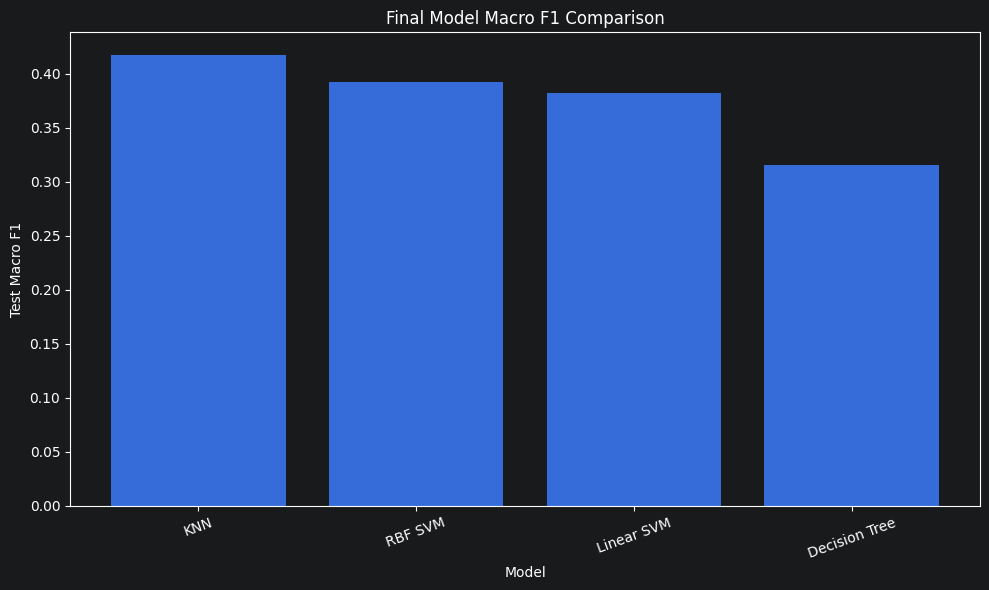

In [77]:
SHOW_STAGE_13_PLOTS = True


plt.figure(figsize=(10, 6))


plt.bar(
    final_model_comparison[
        "algorithm"
    ],
    final_model_comparison[
        "macro_f1"
    ],
)


plt.title("Final Model Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Test Macro F1")
plt.xticks(rotation=20)
plt.tight_layout()


final_model_comparison_figure_path = (
    FIGURES_DIR
    / "13_final_model_macro_f1_comparison.png"
)


plt.savefig(
    final_model_comparison_figure_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_STAGE_13_PLOTS:
    plt.show()


plt.close()

In [78]:
best_svm_cv_result = (
    svm_cv_results
    .sort_values(
        by=[
            "cv_macro_f1_mean",
            "cv_macro_recall_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


best_knn_cv_result = (
    knn_cv_results
    .sort_values(
        by=[
            "cv_macro_f1_mean",
            "cv_macro_recall_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


best_base_model_summary = pd.DataFrame(
    [
        {
            "algorithm": "svm",
            "model_name": best_svm_cv_result[
                "model_name"
            ],
            "dataset_mode": best_svm_cv_result[
                "dataset_mode"
            ],
            "cv_macro_f1": best_svm_cv_result[
                "cv_macro_f1_mean"
            ],
        },
        {
            "algorithm": "knn",
            "model_name": best_knn_cv_result[
                "model_name"
            ],
            "dataset_mode": best_knn_cv_result[
                "dataset_mode"
            ],
            "cv_macro_f1": best_knn_cv_result[
                "cv_macro_f1_mean"
            ],
        },
    ]
)


display(
    best_base_model_summary.round(4)
)

,algorithm,model_name,dataset_mode,cv_macro_f1
0,svm,svm_linear_with_dataset_balanced,with_dataset,0.3876
1,knn,knn_k5_with_dataset,with_dataset,0.3613


In [79]:
IMPUTATION_STRATEGIES = [
    "mean",
    "median",
]


SCALER_NAMES = [
    "standard",
    "minmax",
]


PREPROCESSING_EXPERIMENTS = []


for imputation_strategy in IMPUTATION_STRATEGIES:
    for scaler_name in SCALER_NAMES:
        PREPROCESSING_EXPERIMENTS.append(
            {
                "algorithm": "svm",
                "numeric_imputation_strategy": (
                    imputation_strategy
                ),
                "scaler_name": scaler_name,
            }
        )

        PREPROCESSING_EXPERIMENTS.append(
            {
                "algorithm": "knn",
                "numeric_imputation_strategy": (
                    imputation_strategy
                ),
                "scaler_name": scaler_name,
            }
        )


preprocessing_experiment_table = pd.DataFrame(
    PREPROCESSING_EXPERIMENTS
)


display(preprocessing_experiment_table)

,algorithm,numeric_imputation_strategy,scaler_name
0,svm,mean,standard
1,knn,mean,standard
2,svm,mean,minmax
3,knn,mean,minmax
4,svm,median,standard
5,knn,median,standard
6,svm,median,minmax
7,knn,median,minmax


In [80]:
def select_stage_13_features(
    input_data,
    dataset_mode,
):
    if dataset_mode == "with_dataset":
        return input_data[
            FEATURES_WITH_DATASET
        ].copy()

    if dataset_mode == "without_dataset":
        return input_data[
            FEATURES_WITHOUT_DATASET
        ].copy()

    raise ValueError(
        "Dataset mode must be "
        "'with_dataset' or 'without_dataset'."
    )


def build_stage_13_pipeline(
    algorithm,
    numeric_imputation_strategy,
    scaler_name,
):
    if algorithm == "svm":
        base_result = best_svm_cv_result
    elif algorithm == "knn":
        base_result = best_knn_cv_result
    else:
        raise ValueError(
            "Algorithm must be 'svm' or 'knn'."
        )

    dataset_mode = base_result["dataset_mode"]

    if dataset_mode == "with_dataset":
        categorical_features = (
            CATEGORICAL_FEATURES_WITH_DATASET
        )
    else:
        categorical_features = (
            CATEGORICAL_FEATURES_WITHOUT_DATASET
        )

    preprocessor = build_preprocessor(
        numeric_features=NUMERIC_FEATURES,
        categorical_features=categorical_features,
        numeric_imputation_strategy=(
            numeric_imputation_strategy
        ),
        scaler_name=scaler_name,
    )

    if algorithm == "svm":
        class_weight = (
            None
            if base_result["class_weight"] == "none"
            else "balanced"
        )

        classifier = SVC(
            kernel=base_result["kernel"],
            C=float(base_result["C"]),
            gamma=base_result["gamma"],
            class_weight=class_weight,
            cache_size=1024,
        )

    else:
        classifier = KNeighborsClassifier(
            n_neighbors=int(
                base_result["n_neighbors"]
            ),
            weights=base_result["weights"],
            metric="minkowski",
            p=2,
            n_jobs=1,
        )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

In [81]:
preprocessing_cv_rows = []


for experiment in PREPROCESSING_EXPERIMENTS:
    algorithm = experiment["algorithm"]

    if algorithm == "svm":
        base_result = best_svm_cv_result
    else:
        base_result = best_knn_cv_result

    dataset_mode = base_result["dataset_mode"]

    X_train_candidate = (
        select_stage_13_features(
            input_data=X_train,
            dataset_mode=dataset_mode,
        )
    )

    model_pipeline = build_stage_13_pipeline(
        algorithm=algorithm,
        numeric_imputation_strategy=experiment[
            "numeric_imputation_strategy"
        ],
        scaler_name=experiment["scaler_name"],
    )

    experiment_name = (
        f"{algorithm}_"
        f"{experiment['numeric_imputation_strategy']}_"
        f"{experiment['scaler_name']}"
    )

    start_time = time.perf_counter()

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_train_candidate,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    preprocessing_cv_rows.append(
        {
            "experiment_name": experiment_name,
            "algorithm": algorithm,
            "dataset_mode": dataset_mode,
            "numeric_imputation_strategy": (
                experiment[
                    "numeric_imputation_strategy"
                ]
            ),
            "scaler_name": experiment[
                "scaler_name"
            ],
            "cv_accuracy_mean": (
                cv_result[
                    "test_accuracy"
                ].mean()
            ),
            "cv_balanced_accuracy_mean": (
                cv_result[
                    "test_balanced_accuracy"
                ].mean()
            ),
            "cv_macro_precision_mean": (
                cv_result[
                    "test_macro_precision"
                ].mean()
            ),
            "cv_macro_recall_mean": (
                cv_result[
                    "test_macro_recall"
                ].mean()
            ),
            "cv_macro_f1_mean": (
                cv_result[
                    "test_macro_f1"
                ].mean()
            ),
            "cv_macro_f1_std": (
                cv_result[
                    "test_macro_f1"
                ].std()
            ),
            "cv_weighted_f1_mean": (
                cv_result[
                    "test_weighted_f1"
                ].mean()
            ),
            "elapsed_seconds": elapsed_seconds,
        }
    )

    print(f"Completed: {experiment_name}")

Completed: svm_mean_standard
Completed: knn_mean_standard
Completed: svm_mean_minmax
Completed: knn_mean_minmax
Completed: svm_median_standard
Completed: knn_median_standard
Completed: svm_median_minmax
Completed: knn_median_minmax


In [82]:
preprocessing_cv_results = pd.DataFrame(
    preprocessing_cv_rows
)


preprocessing_cv_results = (
    preprocessing_cv_results
    .sort_values(
        by=[
            "cv_macro_f1_mean",
            "cv_macro_recall_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


best_preprocessing_result = (
    preprocessing_cv_results.iloc[0]
)


display(
    preprocessing_cv_results.round(4)
)


print("Best preprocessing experiment:")
display(
    best_preprocessing_result.to_frame().T
)

,experiment_name,algorithm,dataset_mode,numeric_imputation_strategy,scaler_name,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_macro_precision_mean,cv_macro_recall_mean,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,elapsed_seconds
0,svm_median_standard,svm,with_dataset,median,standard,0.5436,0.3938,0.4016,0.3938,0.3876,0.0471,0.5645,0.6614
1,svm_mean_standard,svm,with_dataset,mean,standard,0.5395,0.4000,0.3958,0.4000,0.3851,0.0522,0.5581,1.0215
2,svm_mean_minmax,svm,with_dataset,mean,minmax,0.5245,0.3951,0.3991,0.3951,0.3794,0.0384,0.5533,0.6912
3,svm_median_minmax,svm,with_dataset,median,minmax,0.5218,0.3828,0.3949,0.3828,0.3738,0.0326,0.5514,0.8741
4,knn_median_standard,knn,with_dataset,median,standard,0.5693,0.3628,0.3896,0.3628,0.3613,0.0305,0.5441,0.5489
5,knn_mean_standard,knn,with_dataset,mean,standard,0.5639,0.3565,0.3860,0.3565,0.3563,0.0371,0.5393,0.9334
6,knn_mean_minmax,knn,with_dataset,mean,minmax,0.5598,0.3410,0.3421,0.3410,0.3333,0.0190,0.5363,0.5883
7,knn_median_minmax,knn,with_dataset,median,minmax,0.5571,0.3392,0.3396,0.3392,0.3313,0.0222,0.5342,0.5264


Best preprocessing experiment:


,experiment_name,algorithm,dataset_mode,numeric_imputation_strategy,scaler_name,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_macro_precision_mean,cv_macro_recall_mean,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,elapsed_seconds
0,svm_median_standard,svm,with_dataset,median,standard,0.543574,0.393779,0.40162,0.393779,0.387551,0.047094,0.564541,0.66144


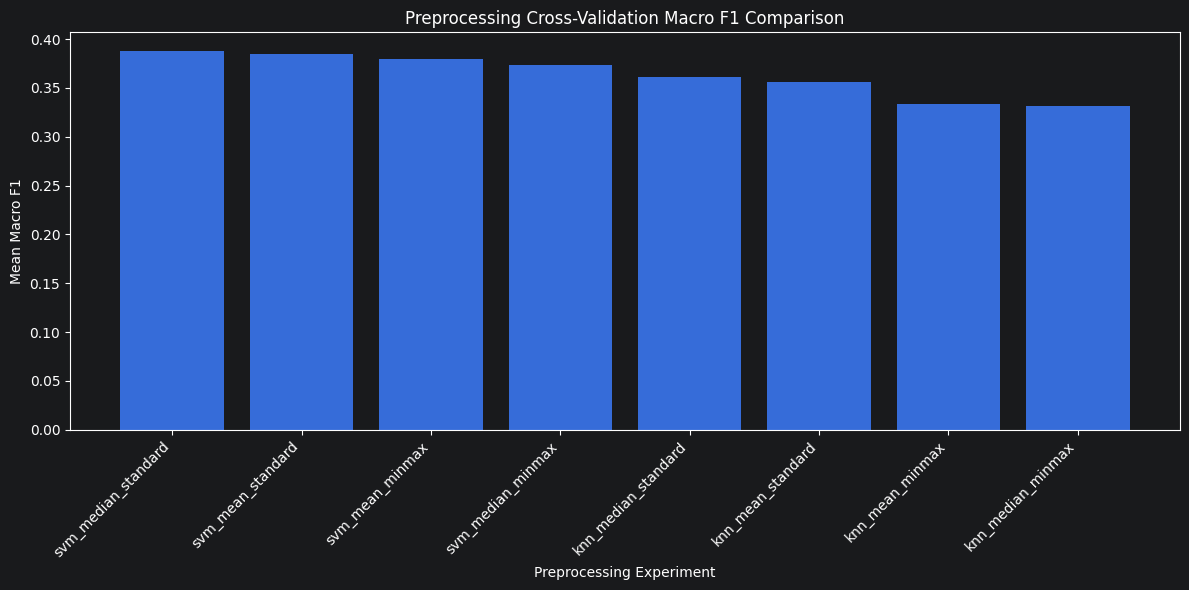

In [83]:
plt.figure(figsize=(12, 6))


plt.bar(
    preprocessing_cv_results[
        "experiment_name"
    ],
    preprocessing_cv_results[
        "cv_macro_f1_mean"
    ],
)


plt.title(
    "Preprocessing Cross-Validation Macro F1 Comparison"
)
plt.xlabel("Preprocessing Experiment")
plt.ylabel("Mean Macro F1")
plt.xticks(
    rotation=45,
    ha="right",
)
plt.tight_layout()


preprocessing_comparison_figure_path = (
    FIGURES_DIR
    / "13_preprocessing_macro_f1_comparison.png"
)


plt.savefig(
    preprocessing_comparison_figure_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_STAGE_13_PLOTS:
    plt.show()


plt.close()

In [84]:
optimized_algorithm = best_preprocessing_result[
    "algorithm"
]


optimized_dataset_mode = (
    best_preprocessing_result[
        "dataset_mode"
    ]
)


optimized_model = build_stage_13_pipeline(
    algorithm=optimized_algorithm,
    numeric_imputation_strategy=(
        best_preprocessing_result[
            "numeric_imputation_strategy"
        ]
    ),
    scaler_name=best_preprocessing_result[
        "scaler_name"
    ],
)


X_train_optimized = select_stage_13_features(
    input_data=X_train,
    dataset_mode=optimized_dataset_mode,
)


X_test_optimized = select_stage_13_features(
    input_data=X_test,
    dataset_mode=optimized_dataset_mode,
)


start_time = time.perf_counter()


optimized_model.fit(
    X_train_optimized,
    y_train,
)


optimized_training_seconds = (
    time.perf_counter() - start_time
)


start_time = time.perf_counter()


optimized_test_predictions = (
    optimized_model.predict(
        X_test_optimized
    )
)


optimized_prediction_seconds = (
    time.perf_counter() - start_time
)


print("Optimized model trained and evaluated successfully.")

Optimized model trained and evaluated successfully.


In [85]:
optimized_model_name = (
    f"optimized_{optimized_algorithm}_"
    f"{best_preprocessing_result['numeric_imputation_strategy']}_"
    f"{best_preprocessing_result['scaler_name']}"
)


optimized_model_test_results = pd.DataFrame(
    [
        {
            "model_name": optimized_model_name,
            "algorithm": (
                f"Optimized "
                f"{optimized_algorithm.upper()}"
            ),
            "model_detail": (
                f"imputation="
                f"{best_preprocessing_result['numeric_imputation_strategy']}"
                f" | scaler="
                f"{best_preprocessing_result['scaler_name']}"
                f" | dataset="
                f"{optimized_dataset_mode}"
            ),
            "accuracy": accuracy_score(
                y_test,
                optimized_test_predictions,
            ),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    y_test,
                    optimized_test_predictions,
                )
            ),
            "macro_precision": precision_score(
                y_test,
                optimized_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "macro_recall": recall_score(
                y_test,
                optimized_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "macro_f1": f1_score(
                y_test,
                optimized_test_predictions,
                labels=CLASS_LABELS,
                average="macro",
                zero_division=0,
            ),
            "weighted_f1": f1_score(
                y_test,
                optimized_test_predictions,
                labels=CLASS_LABELS,
                average="weighted",
                zero_division=0,
            ),
            "training_seconds": (
                optimized_training_seconds
            ),
            "prediction_seconds": (
                optimized_prediction_seconds
            ),
        }
    ]
)


optimized_classification_report = (
    pd.DataFrame(
        classification_report(
            y_test,
            optimized_test_predictions,
            labels=CLASS_LABELS,
            target_names=[
                "class_0",
                "class_1",
                "class_2",
                "class_3",
                "class_4",
            ],
            output_dict=True,
            zero_division=0,
        )
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "report_row",
        }
    )
)


optimized_class_4_recall = float(
    optimized_classification_report.loc[
        optimized_classification_report[
            "report_row"
        ] == "class_4",
        "recall",
    ].iloc[0]
)


optimized_model_test_results[
    "class_4_recall"
] = optimized_class_4_recall


display(
    optimized_model_test_results.round(4)
)

,model_name,algorithm,model_detail,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds,class_4_recall
0,optimized_svm_median_standard,Optimized SVM,imputation=median | scaler=standard | dataset=...,0.5054,0.4453,0.391,0.4453,0.3818,0.5364,0.1006,0.0203,0.6667


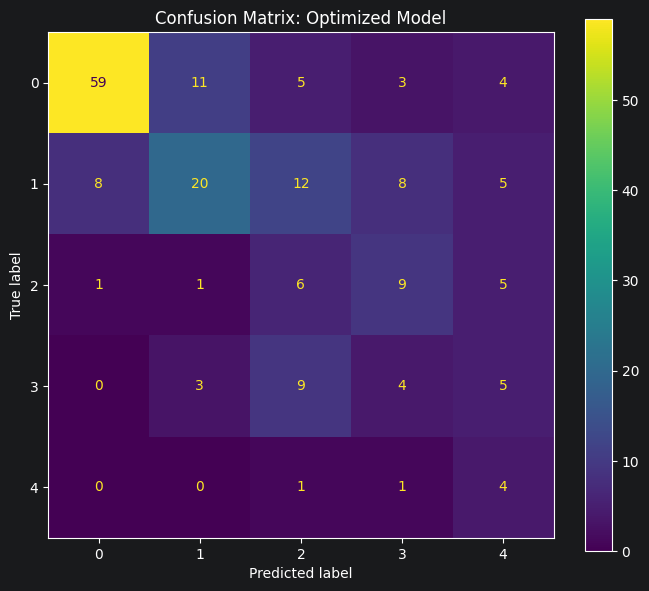

In [86]:
figure, axis = plt.subplots(
    figsize=(7, 6)
)


ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=optimized_test_predictions,
    labels=CLASS_LABELS,
    display_labels=CLASS_LABELS,
    values_format="d",
    ax=axis,
)


axis.set_title(
    "Confusion Matrix: Optimized Model"
)


figure.tight_layout()


optimized_confusion_matrix_path = (
    FIGURES_DIR
    / "13_optimized_model_confusion_matrix.png"
)


figure.savefig(
    optimized_confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)


if SHOW_STAGE_13_PLOTS:
    plt.show()


plt.close(figure)

In [87]:
expanded_model_comparison = pd.concat(
    [
        final_model_comparison,
        optimized_model_test_results[
            final_model_comparison.columns
        ],
    ],
    ignore_index=True,
)


expanded_model_comparison = (
    expanded_model_comparison
    .sort_values(
        by=[
            "macro_f1",
            "class_4_recall",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


recommended_model_summary = (
    expanded_model_comparison
    .head(1)
    .copy()
)


recommended_model_summary.insert(
    0,
    "selection_rank",
    1,
)


print("Final model comparison:")
display(
    expanded_model_comparison.round(4)
)


print("Recommended model:")
display(
    recommended_model_summary.round(4)
)

Final model comparison:


,model_name,algorithm,model_detail,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds,class_4_recall
0,knn_k5_with_dataset,KNN,k=5 | dataset=with_dataset,0.5924,0.3997,0.5665,0.3997,0.4172,0.5782,0.0614,0.1222,0.1667
1,svm_rbf_with_dataset_balanced,RBF SVM,kernel=rbf | dataset=with_dataset | class_weig...,0.5380,0.4054,0.3998,0.4054,0.3918,0.5657,0.0829,0.0782,0.1667
2,optimized_svm_median_standard,Optimized SVM,imputation=median | scaler=standard | dataset=...,0.5054,0.4453,0.3910,0.4453,0.3818,0.5364,0.1006,0.0203,0.6667
3,svm_linear_with_dataset_balanced,Linear SVM,kernel=linear | dataset=with_dataset | class_w...,0.5054,0.4453,0.3910,0.4453,0.3818,0.5364,0.0948,0.0237,0.6667
4,decision_tree_depth_5_with_dataset_none,Decision Tree,depth=5 | dataset=with_dataset | class_weight=...,0.5598,0.3432,0.2964,0.3432,0.3155,0.5286,0.0543,0.0415,0.0000


Recommended model:


,selection_rank,model_name,algorithm,model_detail,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds,prediction_seconds,class_4_recall
0,1,knn_k5_with_dataset,KNN,k=5 | dataset=with_dataset,0.5924,0.3997,0.5665,0.3997,0.4172,0.5782,0.0614,0.1222,0.1667


In [88]:
optimized_model_path = (
    MODELS_DIR
    / "13_optimized_model.joblib"
)


joblib.dump(
    optimized_model,
    optimized_model_path,
)


final_model_comparison.to_csv(
    TABLES_DIR
    / "13_initial_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)


preprocessing_cv_results.to_csv(
    TABLES_DIR
    / "13_preprocessing_cv_results.csv",
    index=False,
    encoding="utf-8-sig",
)


best_preprocessing_result.to_frame().T.to_csv(
    TABLES_DIR
    / "13_best_preprocessing_configuration.csv",
    index=False,
    encoding="utf-8-sig",
)


optimized_model_test_results.to_csv(
    TABLES_DIR
    / "13_optimized_model_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)


optimized_classification_report.to_csv(
    TABLES_DIR
    / "13_optimized_classification_report.csv",
    index=False,
    encoding="utf-8-sig",
)


expanded_model_comparison.to_csv(
    TABLES_DIR
    / "13_final_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)


recommended_model_summary.to_csv(
    TABLES_DIR
    / "13_recommended_model_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


print("Stage 13 outputs saved successfully.")
print(optimized_model_path)

Stage 13 outputs saved successfully.
E:\Projects\DataMining\outputs\models\13_optimized_model.joblib


In [89]:
assert len(final_model_comparison) == 4, (
    "The initial model comparison must contain four models."
)


assert len(preprocessing_cv_results) == 8, (
    "The preprocessing comparison must contain eight experiments."
)


assert set(
    preprocessing_cv_results[
        "numeric_imputation_strategy"
    ]
) == {
    "mean",
    "median",
}, (
    "Both mean and median imputation must be evaluated."
)


assert set(
    preprocessing_cv_results[
        "scaler_name"
    ]
) == {
    "standard",
    "minmax",
}, (
    "Both StandardScaler and MinMaxScaler must be evaluated."
)


assert len(optimized_model_test_results) == 1, (
    "Exactly one optimized model must be evaluated."
)


assert len(expanded_model_comparison) == 5, (
    "The expanded comparison must contain five rows."
)


assert len(recommended_model_summary) == 1, (
    "Exactly one final model must be recommended."
)


metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "class_4_recall",
]


metric_values = expanded_model_comparison[
    metric_columns
]


assert (
    (
        (metric_values >= 0)
        & (metric_values <= 1)
    )
    .all()
    .all()
), (
    "All evaluation metrics must be between zero and one."
)


required_output_files = [
    TABLES_DIR
    / "13_initial_model_comparison.csv",
    TABLES_DIR
    / "13_preprocessing_cv_results.csv",
    TABLES_DIR
    / "13_best_preprocessing_configuration.csv",
    TABLES_DIR
    / "13_optimized_model_test_results.csv",
    TABLES_DIR
    / "13_optimized_classification_report.csv",
    TABLES_DIR
    / "13_final_model_comparison.csv",
    TABLES_DIR
    / "13_recommended_model_summary.csv",
    FIGURES_DIR
    / "13_final_model_macro_f1_comparison.png",
    FIGURES_DIR
    / "13_preprocessing_macro_f1_comparison.png",
    FIGURES_DIR
    / "13_optimized_model_confusion_matrix.png",
    optimized_model_path,
]


for output_file in required_output_files:
    assert output_file.exists(), (
        f"Expected output file was not created: {output_file}"
    )


print("All Stage 13 validation checks passed.")

All Stage 13 validation checks passed.
